In [1]:
import glob
import pickle
from room_type import RoomType
from classifier_fusion_type import ClassifierFusionType
from hard_class_behaviour import HardClassBehaviour
from ml_model_type import MLModelType
import random
import numpy as np

def find_observed_point_by_pose(pose, room_points):
    #(pos, rot) = pose # ((10.75, 1.57599937915802, 1.0), (30.000003814697266, 0.0, 0))
    result = None
    for rp in room_points:
        if rp['point_pose'] == pose:
            result = rp
            return result
    return result

##
# This looks at the specified pkl file collection per LLM or VLM type and then calculates accuracies within that collection.
# In VLM files we also normally have SVC and LLM data so we can calculate that at the same time.
##
def process_scene_files(llm_type, 
                        fusion_type = ClassifierFusionType.NO_FUSION, 
                        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY):
    #pkl_mistral = "pkl_mistral/diff*.pkl"
    pkl_store = "experiment_data/pkl_" + llm_type + "/scene_descr_train_*.pkl"
    #print(glob.glob(pkl_gemma)) 

    accuracies_per_room_llm = []
    accuracies_per_room_svc = []
    accuracies_per_room_cvm = []
    
    scene_files = glob.glob(pkl_store) # files showing gemma scenes
    #scene_files = ["experiment_data/pkl_" + llm_type + "/scene_descr_train_56.pkl"]

    # per all rooms:
    # good classifications
    all_rooms_llm_good = 0
    all_rooms_svc_good = 0
    all_rooms_cvm_good = 0
    # time taken to classify
    all_rooms_elapsed_time_llm = 0
    all_rooms_elapsed_time_svc = 0
    all_rooms_elapsed_time_cvm = 0
    # how many points were classified in total
    all_rooms_total_points = 0
    # min and max points per habitat across all habitats
    min_points = 10000000000
    max_points = -1
    # min and max object counts per FPV across all habitats
    min_objs_pp = 10000000000
    max_objs_pp = -1

    # min and max elapsed classification times
    min_elapsed_time_llm = 10000000000
    min_elapsed_time_svc = 10000000000
    min_elapsed_time_cvm = 10000000000
    max_elapsed_time_llm = -1
    max_elapsed_time_svc = -1
    max_elapsed_time_cvm = -1

    # a collection of object labels in FPVs that took longest and shortest to process
    max_t_labels = set()
    min_t_labels = set()

    # number of storage and office labels
    storages_and_offices = 0

    # go through all pkl files
    for scene_f in scene_files:
        f = open(scene_f,'rb')
        scene = pickle.load(f)
        #print(scene_f.split("/"))
        f_name = scene_f.split("/")[2]

        # corresponding LLM pkl path for comparison
        cor_llm_pkl_path = "experiment_data/pkl_LLAMA/" + f_name 
        llm_f = open(cor_llm_pkl_path,'rb')
        llm_scene = pickle.load(llm_f)

        room_points = scene.get_all_points() # scene from this (usually VLM) pkl file
        llm_room_points = llm_scene.get_all_points() # scene from the corresponding LLama pkl file

        # per room
        llm_good = 0
        svc_good = 0
        cvm_good = 0
        elapsed_time_llm = 0
        elapsed_time_svc = 0
        elapsed_time_cvm = 0
        total_points = 0

        #print(str(len(room_points)) + " " + str(len(llm_room_points)) + " " + cor_llm_pkl_path + " " + scene_f)
        # go through all data points in a given pkl file
        for rp in room_points:
            # find the same point that we have here (VLM set) in LLM set.
            # If we can find it, then take note of the LLM assigned class.
            # If we can't find it, then LLM didn't classify it because it's an HTC FPV.
            # In that case mark it as RoomType.NOT_CLASSIFIED
            llm_rp = find_observed_point_by_pose(rp['point_pose'], llm_room_points)
            if llm_rp is None: # If we haven't got this point in LLM room point set, then we haven't classified it (because there were no good objects to cllassify on- only common objects, e.g. wall, floor, window)
                llm_rp_room_type = RoomType.NOT_CLASSIFIED
            else:
                llm_rp_room_type = llm_rp["room_type_llm"] # how LLM classified this FPV
            # if we want to skip points that were classified as STORAGE or OFFICE (not categories that we have in ground truth)
            #if (rp["room_type_svc"] == RoomType.NOT_CLASSIFIED or rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    continue

            # if we want to skip points that LLM didn't classify (usually when there are only common objects) a.k.a. HTC FPV.
            # We want to do that when what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_NEITHER because that means we don't
            # want to evaluate CVM answer when the answer was not classified with SVC or LLM either.
            # We still will want to count RoomType.NOT_KNOWN as a wrong classification because that means the answer of LLM was not
            # interpretable although it was not an HTC scene. But if we have RoomType.NOT_CLASSIFIED, then that's an HTC scene.
            if (llm_rp_room_type == RoomType.NOT_CLASSIFIED and what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_NEITHER):
                continue

            # If we want to only classify HTC scenes with CVM and we are running a CVM experiment and this is a hard case, then proceed.
            # If this is not an HTC, then skip.
            if (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM and llm_type != "LLAMA" and llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                continue

            if (what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM and llm_rp_room_type == RoomType.NOT_CLASSIFIED): #  and llm_rp_room_type != RoomType.NOT_KNOWN
                # do we want a guess of 4 or 6 labels?
                if "4" in llm_type:
                    llm_rp_room_type = random.choice(RoomType.all_options(False))
                else:
                    llm_rp_room_type = random.choice(RoomType.all_options())

           # If we want to only classify hard cases with CVM and we are running a CVM experiment and this is a hard case, then proceed, otherwise skip
            if (what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM and llm_type != "LLAMA" and (llm_rp_room_type == RoomType.NOT_CLASSIFIED or llm_rp_room_type == RoomType.NOT_KNOWN)):
                # do we want a guess of 4 or 6 labels?
                # In the end the result that will be counted is the VLM result, so in this case LLM result was HTC, so we want it
                # randomised, so we store the randomised result in the VLM field.
                if "4" in llm_type:
                    rp["room_type_cvm"] = random.choice(RoomType.all_options(False))
                else:
                    rp["room_type_cvm"] = random.choice(RoomType.all_options())
            elif (what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM and llm_type != "LLAMA" and llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                continue
            
            ## if we want to re-classify OFFICE and STORAGE as BEDROOM
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE or rp["room_type_cvm"] == RoomType.NOT_KNOWN):
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    print("MISCLASS: " + rp["room_type_cvm"].name + " " + llm_rp_room_type.name + " " + rp["room_type_gt"].name + " " + str(rp["visible_object_names"]) + " # " + rp['cvm_text'] + " # " + rp["front_view_at_this_point"])
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.BEDROOM

            # if we want to re-classify OFFICE and STORAGE as LIVING ROOM
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.LIVING_ROOM

            # if we want to re-classify OFFICE and STORAGE as KITCHEN
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.KITCHEN

            ## if we want to re-classify OFFICE and STORAGE as BATHROOM
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.BATHROOM

            # Here we will modify the stored result. E.g., if we want to use LLM first and then VLM, in that case
            # We first see if LLM result is there. If it is, then we overwrite VLM result with LLM's and later count
            # that as fused result. If LLM resut is not there, then we leave VLM result as is. Respectively if we want
            # to count VLM result first, then the logic is reversed.
            if (fusion_type == ClassifierFusionType.LLM_THEN_CVM): # if we want to first give LLM a chance and then VLM
                if (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY):
                    # if LLM has answer, then use that, otherwise leave VLM answer to be uses
                    if (llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                        rp["room_type_cvm"] = llm_rp_room_type
                elif (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT):
                    # if LLM has answer, then use that, otherwise leave VLM answer to be uses
                    if (llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                        rp["room_type_cvm"] = llm_rp_room_type
                    elif (llm_rp_room_type == RoomType.NOT_CLASSIFIED): # If LLM didn't return meaningful result (couldn't be parsed) then use VLM result, but if it was HTC case and LLM couldn't do it, then don't count
                        continue
            elif (fusion_type == ClassifierFusionType.CVM_THEN_LLM):
                if (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY):
                    # if we want to combine LLM results with CVM - when CVM doesn't know (NOT_KNOWN or NOT_CLASSIFIED, use LLM result 
                    if (rp["room_type_cvm"] == RoomType.NOT_CLASSIFIED or rp["room_type_cvm"] == RoomType.NOT_KNOWN):
                        rp["room_type_cvm"] = llm_rp_room_type
                elif (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT):
                    # if we want to combine LLM results with CVM - but only when CVM hasn't got a clue (got NOT_KNOWN), use CVM result
                    if (rp["room_type_cvm"] == RoomType.NOT_KNOWN):
                        rp["room_type_cvm"] = llm_rp_room_type
                    elif (rp["room_type_cvm"] == RoomType.NOT_CLASSIFIED):
                        continue
            
            total_points += 1 # total points per habitat
            all_rooms_total_points += 1 # total points across all habitats
            
            # counting correct classifications per method
            if rp["room_type_gt"] == llm_rp_room_type:
                llm_good += 1
                all_rooms_llm_good += 1
            #if rp["room_type_llm"] != rp["room_type_svc"] and rp["room_type_llm"] != rp["room_type_gt"]:
                #print(rp["room_type_llm"].name + " # " + rp["room_type_svc"].name + " # " + rp["room_type_gt"].name + " # " + str(rp["elapsed_time_llm"]) + " # " + str(rp["elapsed_time_svc"]))
                #print(rp["visible_object_names"])
            
            if rp["room_type_gt"] == rp["room_type_svc"]:
                svc_good += 1
                all_rooms_svc_good += 1

            #if (llm_type.type_of_model() == MLModelType.LLM and rp["room_type_gt"] == rp["room_type_cvm"]):
            if (llm_type != "LLAMA" and rp["room_type_gt"] == rp["room_type_cvm"]):
                cvm_good += 1
                all_rooms_cvm_good += 1

            # collecting inference time
            elapsed_time_llm += rp["elapsed_time_llm"]
            elapsed_time_svc += rp["elapsed_time_svc"]
            
            if (llm_type != "LLAMA"): elapsed_time_cvm += rp["elapsed_time_cvm"]
            all_rooms_elapsed_time_llm += rp["elapsed_time_llm"]
            all_rooms_elapsed_time_svc += rp["elapsed_time_svc"]
            if (llm_type != "LLAMA"): all_rooms_elapsed_time_cvm += rp["elapsed_time_cvm"]

            # collecting min and max visible objects per point
            if min_objs_pp > len(rp["visible_object_names"]):
                min_objs_pp = len(rp["visible_object_names"])
    
            if max_objs_pp < len(rp["visible_object_names"]):
                max_objs_pp = len(rp["visible_object_names"])

            # collecting min and max inference time
            if min_elapsed_time_llm > rp["elapsed_time_llm"]:
                min_elapsed_time_llm = rp["elapsed_time_llm"]
                min_t_labels = rp["visible_object_names"]
            if max_elapsed_time_llm < rp["elapsed_time_llm"]:
                max_elapsed_time_llm = rp["elapsed_time_llm"]
                max_t_labels = rp["visible_object_names"]
            if min_elapsed_time_svc > rp["elapsed_time_svc"]:
                min_elapsed_time_svc = rp["elapsed_time_svc"]
            if max_elapsed_time_svc < rp["elapsed_time_svc"]:
                max_elapsed_time_svc = rp["elapsed_time_svc"]
            if (llm_type != "LLAMA" and min_elapsed_time_cvm > rp["elapsed_time_cvm"]):
                min_elapsed_time_cvm = rp["elapsed_time_cvm"]
            if (llm_type != "LLAMA" and max_elapsed_time_cvm < rp["elapsed_time_cvm"]):
                max_elapsed_time_cvm = rp["elapsed_time_cvm"]
        
        #print("llm_good = " + str(llm_good / total_points) + " # " + "svc_good = " + str(svc_good / total_points) + " # llm_time_avg = " + str(elapsed_time_llm / total_points) + " # svc_time_avg = " + str(elapsed_time_svc / total_points))

        # collecting min and max points per habitat
        if min_points > total_points:
            min_points = total_points

        if max_points < total_points:
            max_points = total_points

        # calculating mean accuracy per method
        accuracies_per_room_llm.append(llm_good / total_points)
        accuracies_per_room_svc.append(svc_good / total_points)
        accuracies_per_room_cvm.append(cvm_good / total_points)

        llm_f.close()
        f.close()
        #print("\n")
    #print("min_points = " + str(min_points) + " # " + " max_points = " + str(max_points) + " # total_total_points=" + str(total_total_points))
    #print("min_objs_pp = " + str(min_objs_pp) + " # " + " max_objs_pp = " + str(max_objs_pp))
    #print("min_elapsed_time_llm = " + str(min_elapsed_time_llm) + " # " + "max_elapsed_time_llm = " + str(max_elapsed_time_llm))
    #print("min_elapsed_time_svc = " + str(min_elapsed_time_svc) + " # " + "max_elapsed_time_svc = " + str(max_elapsed_time_svc))
    #print("min_elapsed_time_cvm = " + str(min_elapsed_time_cvm) + " # " + "max_elapsed_time_cvm = " + str(max_elapsed_time_cvm))
    
    #print("min_t_labels = " + str(min_t_labels) + " # " + "max_t_labels = " + str(max_t_labels))
    #print("storages_and_offices = " + str(storages_and_offices) + " # " + "max_t_labels = " + str(max_t_labels))
    
    #print("mean llm time: " + str(all_rooms_elapsed_time_llm / all_rooms_total_points) + " mean svc time: " + str(all_rooms_elapsed_time_svc / all_rooms_total_points))

    #print("min_points = " + str(min_points) + " # " + "max_points = " + str(max_points))

    # returning mean calculated accuracies and mean inference times
    return (accuracies_per_room_llm, # mean values of mean accuracies
            accuracies_per_room_svc, 
            accuracies_per_room_cvm, 
            (all_rooms_elapsed_time_llm / all_rooms_total_points), # avg times
            (all_rooms_elapsed_time_svc / all_rooms_total_points), 
            (all_rooms_elapsed_time_cvm / all_rooms_total_points), 
            storages_and_offices, # how many storages and offices we had (important for CVM deviation from 4 labels)
            [(all_rooms_llm_good / all_rooms_total_points), (all_rooms_svc_good / all_rooms_total_points), (all_rooms_cvm_good / all_rooms_total_points)]) # normal mean accuracies
#scene_descr_llm_fname = "pkl_mistral/scene_descriptions_llm.pkl"
#scene_descr_svc_fname = "pkl_mistral/scene_descriptions_svc.pkl"
#if (os.path.isfile(scene_descr_llm_fname) and os.path.isfile(scene_descr_svc_fname)):
#    file_llm = open(scene_descr_llm_fname,'rb')
#    file_svc = open(scene_descr_svc_fname,'rb')
#    scene_descriptions_llm = pickle.load(file_llm)

#process_scene_files("mistral")
#process_scene_files("gemma")
#process_scene_files("CHAMELEON")
#process_scene_files("CHAMELEON_full_prompt")
#process_scene_files("MOONDREAM_full_prompt")
#process_scene_files("LLAMA")
#process_scene_files("MOONDREAM_one_word")
num_experiments = 2
res_total = 0
for i in range(num_experiments):
    results = process_scene_files("CHAMELEON_p_cot_0lbl_img_end_nf4", what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM)
    #print(results)
    #process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)    
    res_total += np.mean(results[0])
print("mean accuracy of LLM_with_HTC_guessed: ", (res_total / num_experiments))

# We usually want to run this function with fusion_type = ClassifierFusionType.LLM_THEN_CVM or
# fusion_type = ClassifierFusionType.NO_FUSION
# and with what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY or
# what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM or
# what_to_do_with_hard_scenes == CLASSIFY_HARD_CASES_ONLY_CVM
# 
# *(1) fusion_type = ClassifierFusionType.LLM_THEN_CVM and what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY
#     First check LLM result and if it there isn't one, then use VLM result ----------- LLM, then CVM hybrid
#
# *(2) what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_NEITHER: Skip all HTC cases and return LLM, SVC and CVM results.
#          fusion_type = *ANY* ---------------- NON HTC only
#
# *(3) what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM: Classify only HTC cases and use VLM for that.
#          fusion_type = *ANY* ------------ HTC only
#
# *(4) what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM: Look at LLM results only and guess HTC scenes.
#          fusion_type = *ANY* ----------- LLM + HTC guessed
#
# (5) what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM: Look at HTC scenes only and guess them. Result in VLM field.
#          fusion_type = *ANY* ------------ Pure Guesswork in the space of HTC
# 
# (6) what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT: Take LLM results mostly, but when LLM couldn't classify (NOT_KNOWN rather than HTC case), then use VLM
#          fusion_type = ClassifierFusionType.LLM_THEN_CVM ------------ EXOTIC
# 
# (7) what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT: Take CVM results mostly, but when CVM couldn't classify (NOT_KNOWN rather than HTC case), then use LLM
#          fusion_type = ClassifierFusionType.CVM_THEN_LLM ----------------- EXOTIC
#
# (8) what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY: Take CVM results, but when CVM has an HTC case, then use LLM
#          fusion_type = ClassifierFusionType.CVM_THEN_LLM ----------------- EXOTIC
#
# (9) what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY: Classify all (including HTC) with VLM only
#          fusion_type = ClassifierFusionType.NO_FUSION --------------- PURE VLM results

mean accuracy of LLM_with_HTC_guessed:  0.6385716978626543


normal_mean_scores =  [0.0, 0.0, 0.20297029702970298]  median_score_vlm =  0.21212121212121213  ::  CHAMELEON_p_cot_0lbl_img_end_nf4
normal_mean_scores =  [0.0, 0.0, 0.23102310231023102]  median_score_vlm =  0.2  ::  CHAMELEON_p_cot_0lbl_img_middle_nf4
normal_mean_scores =  [0.0, 0.0, 0.22772277227722773]  median_score_vlm =  0.20833333333333334  ::  CHAMELEON_p_cot_0lbl_img_middle
normal_mean_scores =  [0.0, 0.0, 0.28052805280528054]  median_score_vlm =  0.25  ::  CHAMELEON_p_cot_4lbl_img_end_nf4
normal_mean_scores =  [0.0, 0.0, 0.3118811881188119]  median_score_vlm =  0.2727272727272727  ::  CHAMELEON_p_cot_4lbl_img_middle_nf4
normal_mean_scores =  [0.0, 0.0, 0.3448844884488449]  median_score_vlm =  0.3333333333333333  ::  CHAMELEON_p_cot_4lbl_img_middle
normal_mean_scores =  [0.0, 0.0, 0.21947194719471946]  median_score_vlm =  0.16666666666666666  ::  CHAMELEON_p_cot_6lbl_img_end_nf4
normal_mean_scores =  [0.0, 0.0, 0.27887788778877887]  median_score_vlm =  0.25  ::  CHAMELEON_p_cot

/tmp/ipykernel_2934/960574974.py:37: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


normal_mean_scores =  [0.0, 0.0, 0.23927392739273928]  median_score_vlm =  0.17647058823529413  ::  MOONDREAM_p_nocot_4lbl
normal_mean_scores =  [0.0, 0.0, 0.22112211221122113]  median_score_vlm =  0.23529411764705882  ::  MOONDREAM_p_nocot_6lbl


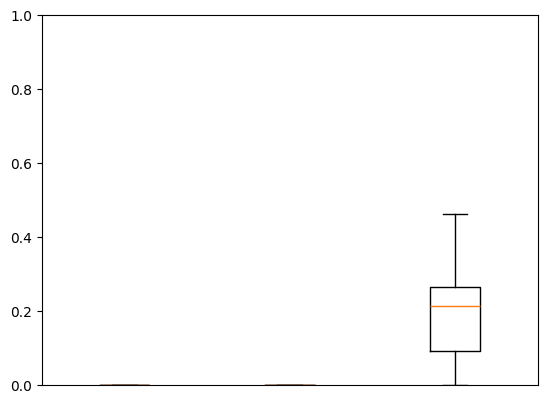

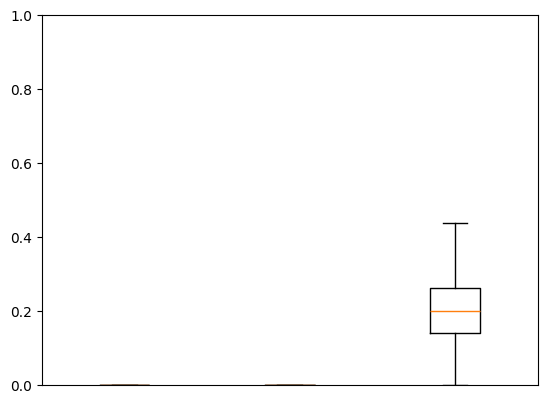

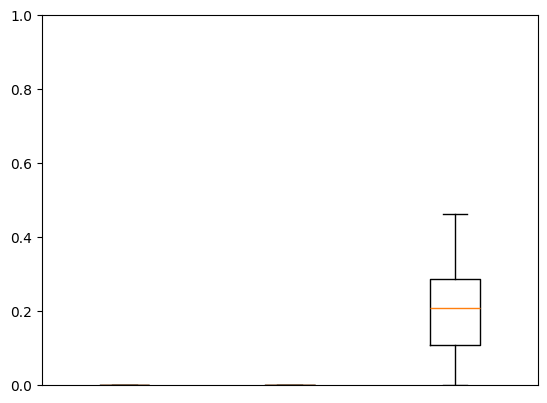

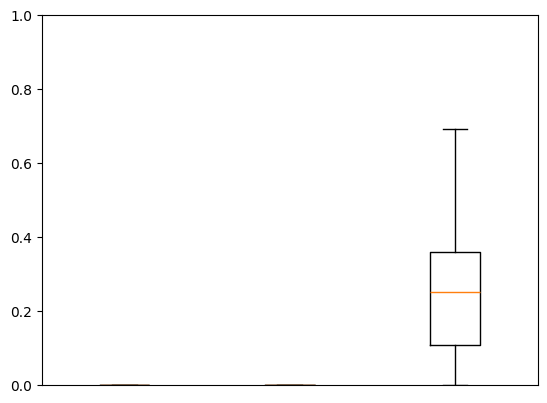

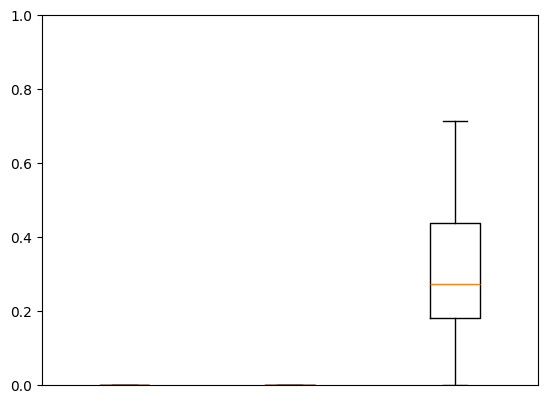

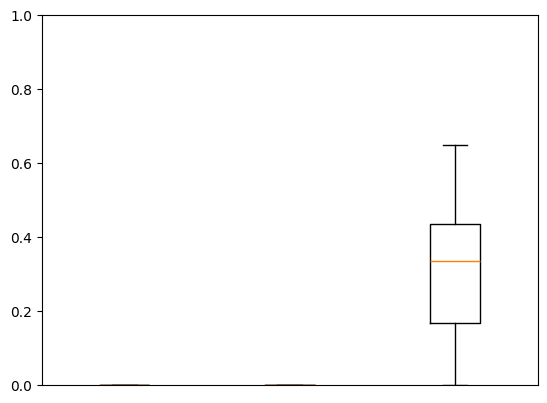

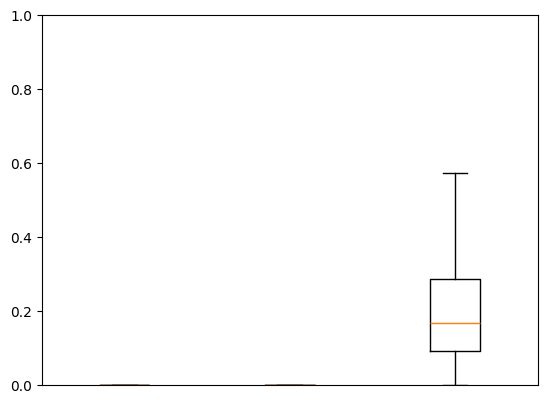

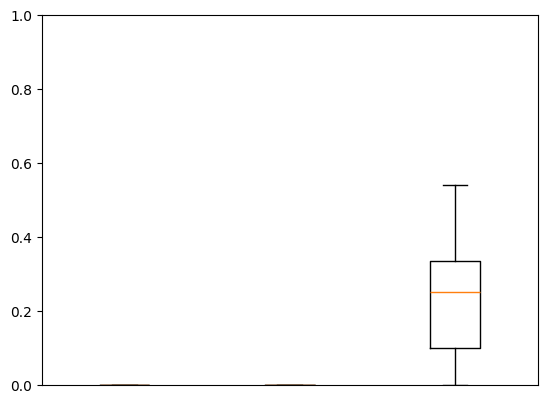

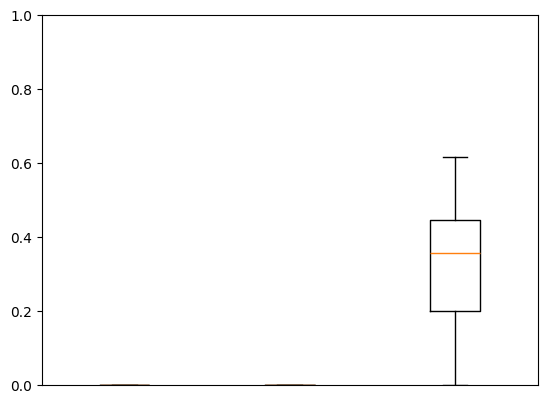

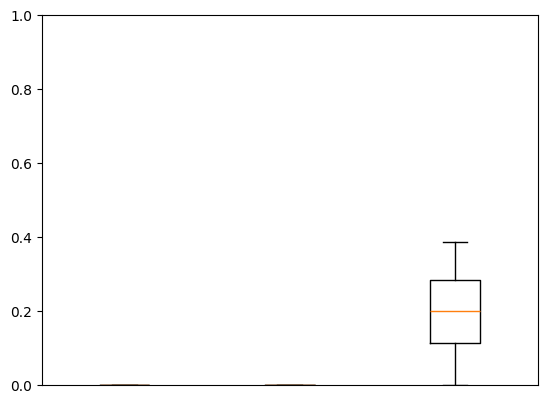

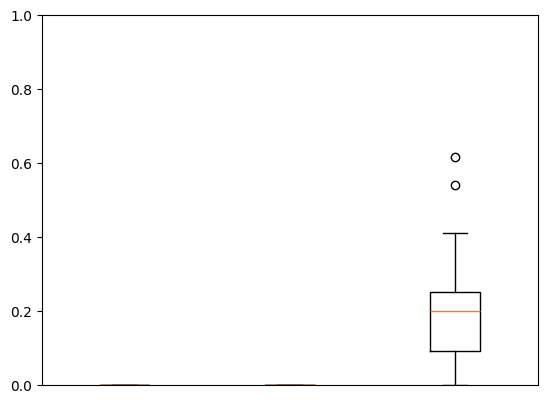

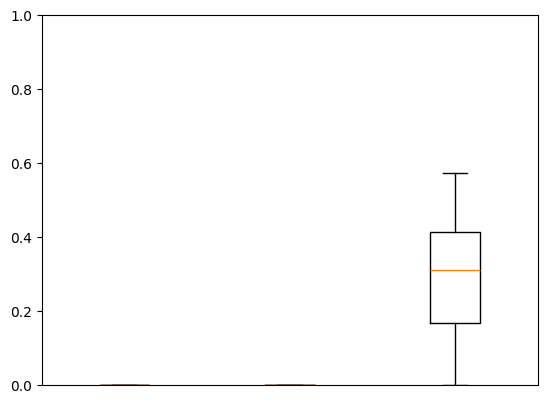

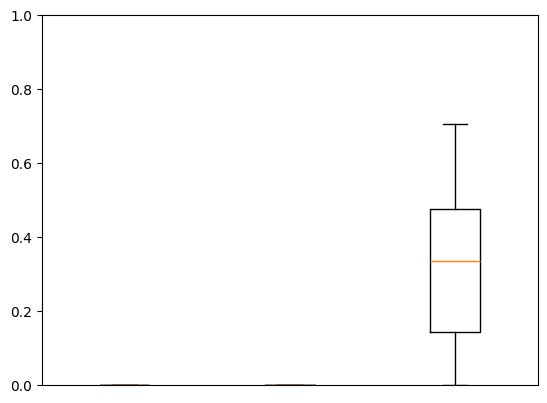

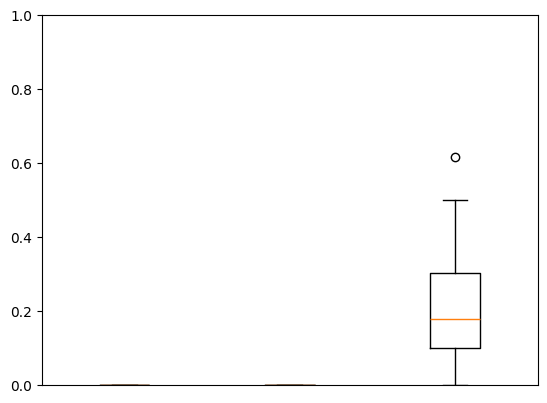

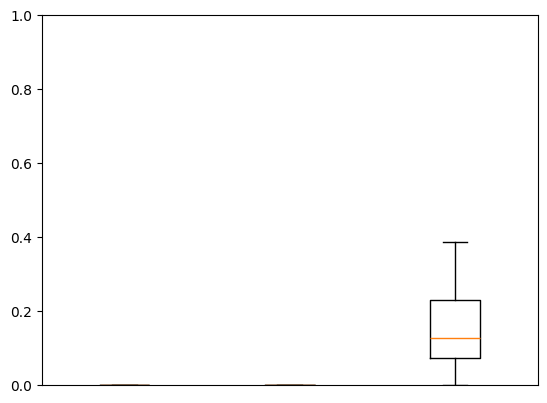

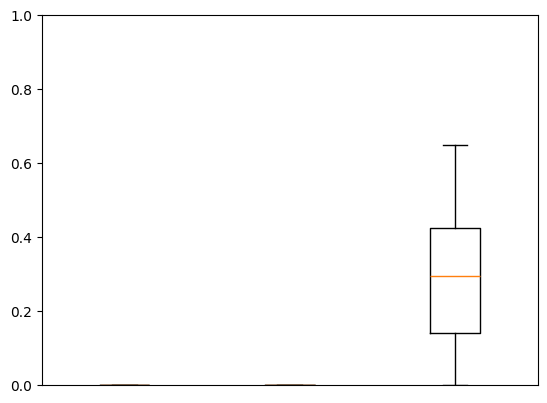

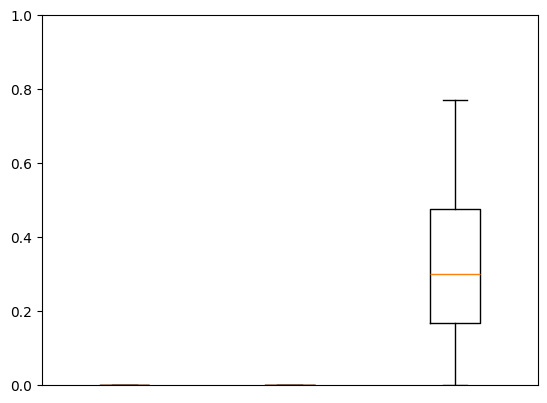

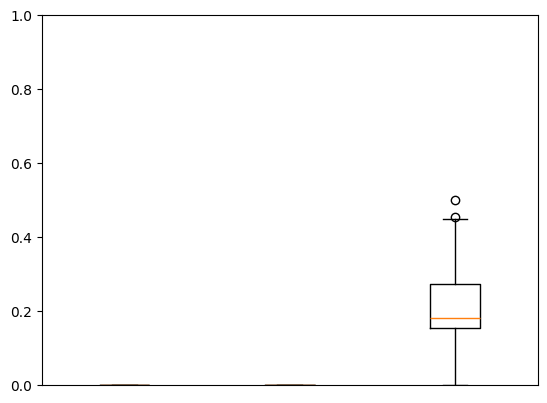

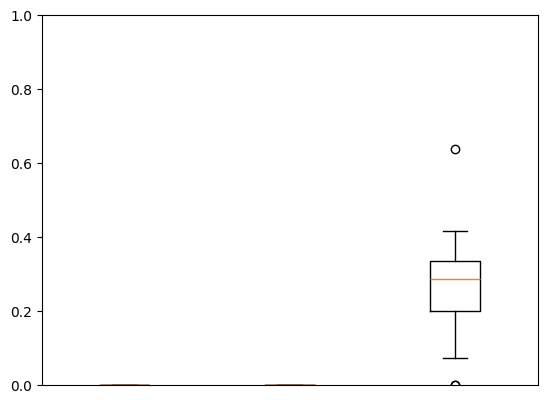

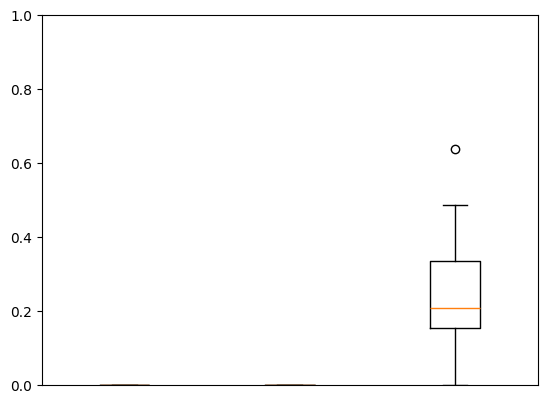

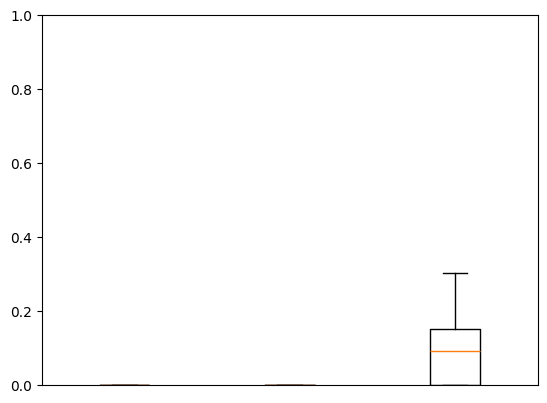

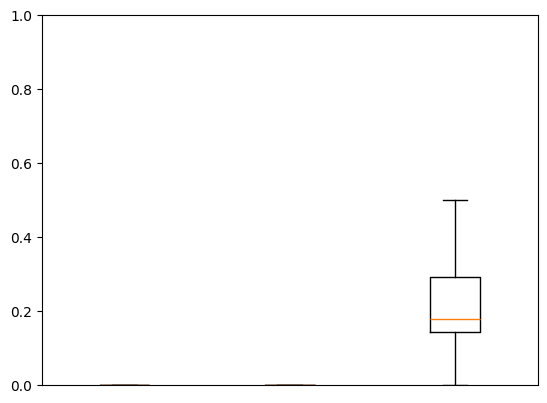

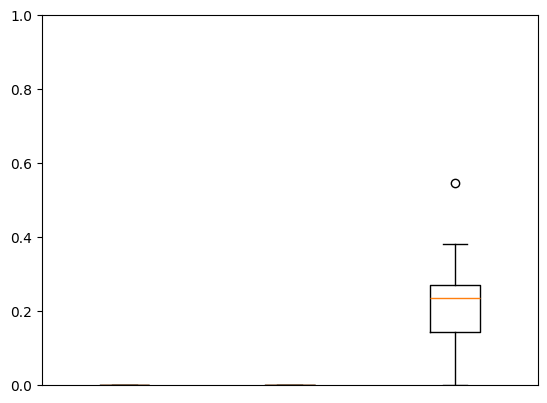

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import mean

##
# This function will create a box plot for given VLM type accuracies for room classification.
# It will only use HTC cases and only VLM.
##
def testRoomClassifierAccuracy_HTC_only_VLM_only(llm_type):
    (llm_accuracies, 
     svc_accuracies, 
     cvm_accuracies, 
     llm_mean_time, 
     svc_mean_time, 
     cvm_mean_time, 
     storages_and_offices, 
     normal_mean_scores) = process_scene_files(llm_type, 
                                               what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
    # should be 3 volumes -- one for LLM and one for SVC and one for CVM for accuracies compared to ground truth.
    number_of_dataset_volumes = 3

    # How many rooms were classified
    number_of_tests_per_dataset_volume = len(llm_accuracies)

    # We'll create an empty Numpy array and put the our SVC accuracies into there.
    dataset_test_results = np.zeros(shape=(number_of_dataset_volumes, number_of_tests_per_dataset_volume))
    #print(dataset_test_results.shape)

    dataset_test_results[0] = llm_accuracies
    dataset_test_results[1] = svc_accuracies
    dataset_test_results[2] = cvm_accuracies

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    print("normal_mean_scores = ", normal_mean_scores, " median_score_vlm = ",np.median(cvm_accuracies) ," :: ", llm_type)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    ax.boxplot(dataset_test_results)
    plt.ylim(0.0, 1.0)
    #plt.show()


#CHAMELEON_p_cot_0lbl_img_end_nf4
#CHAMELEON_p_cot_0lbl_img_middle_nf4
#CHAMELEON_p_cot_0lbl_img_middle
#CHAMELEON_p_cot_4lbl_img_end_nf4
#CHAMELEON_p_cot_4lbl_img_middle_nf4
#CHAMELEON_p_cot_4lbl_img_middle
#CHAMELEON_p_cot_6lbl_img_end_nf4
#CHAMELEON_p_cot_6lbl_img_middle_nf4
#CHAMELEON_p_cot_6lbl_img_middle
#CHAMELEON_p_nocot_0lbl_nf4
#CHAMELEON_p_nocot_0lbl
#CHAMELEON_p_nocot_4lbl_img_end_nf4
#CHAMELEON_p_nocot_4lbl_img_middle_nf4
#CHAMELEON_p_nocot_4lbl_img_middle
#CHAMELEON_p_nocot_6lbl_img_end_nf4
#CHAMELEON_p_nocot_6lbl_img_middle_nf4
#CHAMELEON_p_nocot_6lbl_img_middle
#MOONDREAM_p_cot_0lbl
#MOONDREAM_p_cot_4lbl
#MOONDREAM_p_cot_6lbl
#MOONDREAM_p_nocot_0lbl
#MOONDREAM_p_nocot_4lbl
#MOONDREAM_p_nocot_6lbl

testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_0lbl_img_end_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_0lbl_img_middle_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_0lbl_img_middle")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_4lbl_img_end_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_4lbl_img_middle_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_4lbl_img_middle")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_6lbl_img_end_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_6lbl_img_middle_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_cot_6lbl_img_middle")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_0lbl_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_0lbl")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_4lbl_img_end_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_4lbl_img_middle_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_4lbl_img_middle")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_6lbl_img_end_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_6lbl_img_middle_nf4")
testRoomClassifierAccuracy_HTC_only_VLM_only("CHAMELEON_p_nocot_6lbl_img_middle")
testRoomClassifierAccuracy_HTC_only_VLM_only("MOONDREAM_p_cot_0lbl")
testRoomClassifierAccuracy_HTC_only_VLM_only("MOONDREAM_p_cot_4lbl")
testRoomClassifierAccuracy_HTC_only_VLM_only("MOONDREAM_p_cot_6lbl")
testRoomClassifierAccuracy_HTC_only_VLM_only("MOONDREAM_p_nocot_0lbl")
testRoomClassifierAccuracy_HTC_only_VLM_only("MOONDREAM_p_nocot_4lbl")
testRoomClassifierAccuracy_HTC_only_VLM_only("MOONDREAM_p_nocot_6lbl")

normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6249705535924617]  ::  CHAMELEON_p_cot_0lbl_img_end_nf4
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6289752650176679]  ::  CHAMELEON_p_cot_0lbl_img_middle_nf4
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6285041224970553]  ::  CHAMELEON_p_cot_0lbl_img_middle
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6360424028268551]  ::  CHAMELEON_p_cot_4lbl_img_end_nf4
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6405182567726737]  ::  CHAMELEON_p_cot_4lbl_img_middle_nf4
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6452296819787986]  ::  CHAMELEON_p_cot_4lbl_img_middle
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6273262661955241]  ::  CHAMELEON_p_cot_6lbl_img_end_nf4
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6358068315665489]  ::  CHAMELEON_p_cot_6lbl_img_middle_nf4
normal_mean_scores =  [0.

/tmp/ipykernel_2934/645388674.py:34: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6301531213191991]  ::  MOONDREAM_p_nocot_4lbl
normal_mean_scores =  [0.5959952885747939, 0.5347467608951708, 0.6275618374558304]  ::  MOONDREAM_p_nocot_6lbl


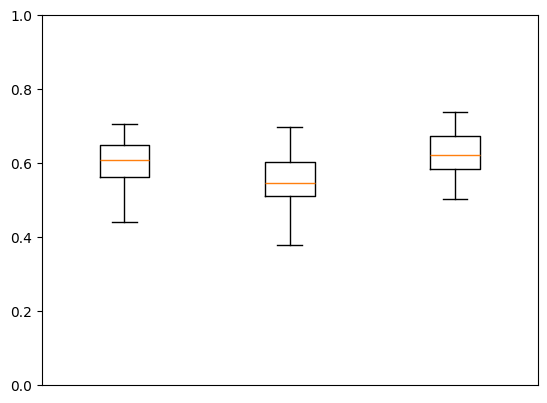

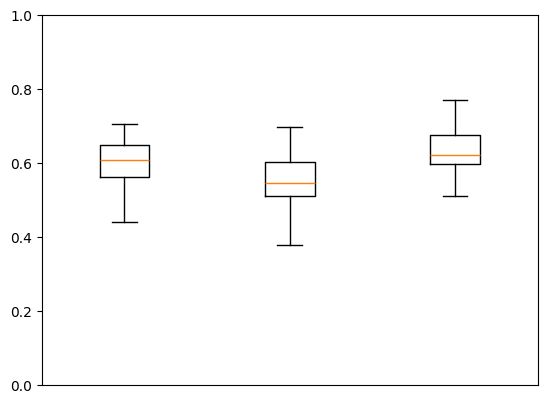

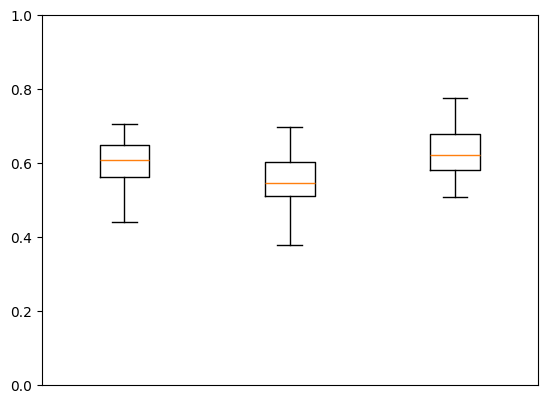

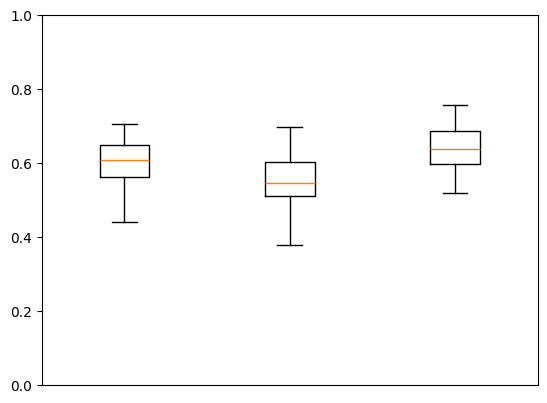

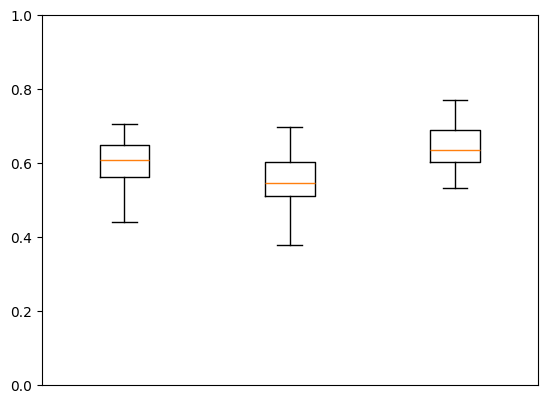

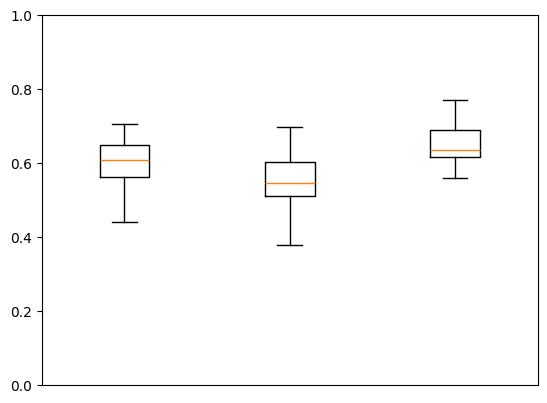

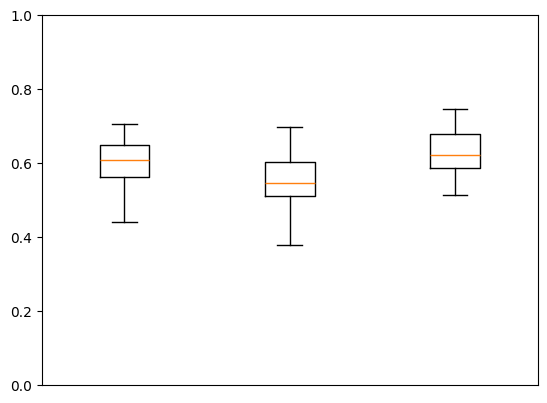

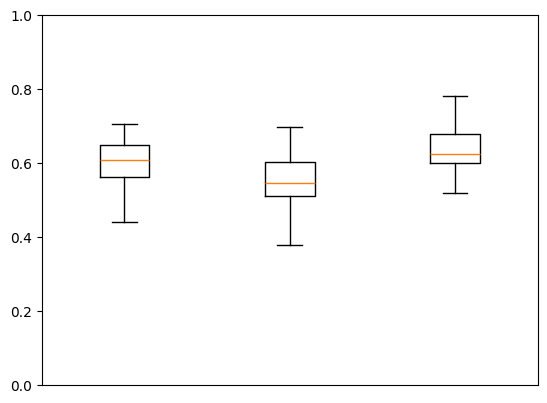

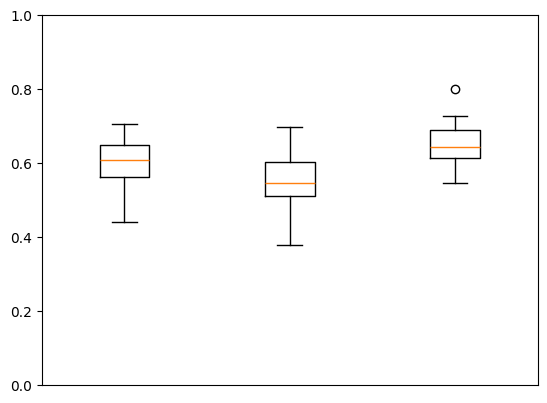

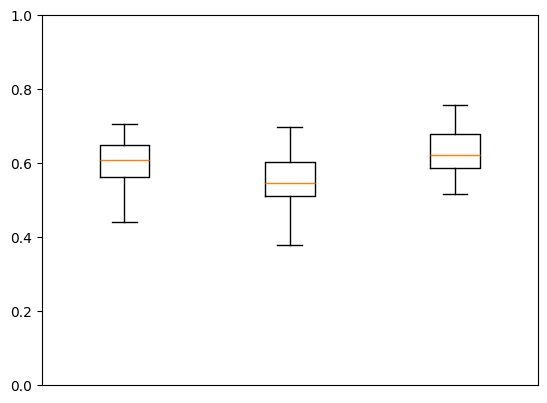

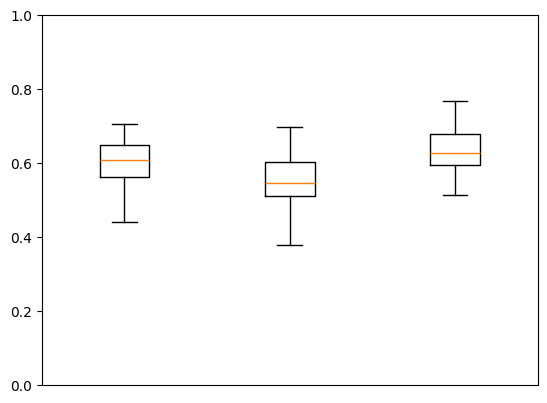

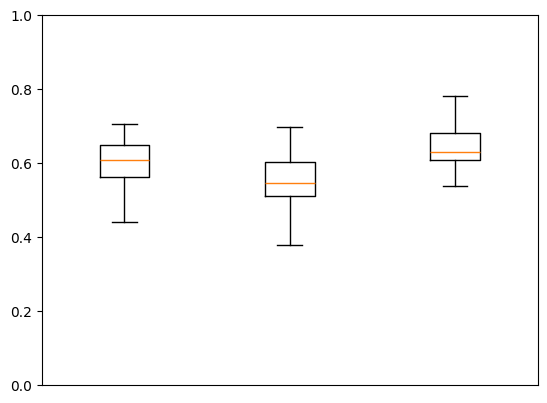

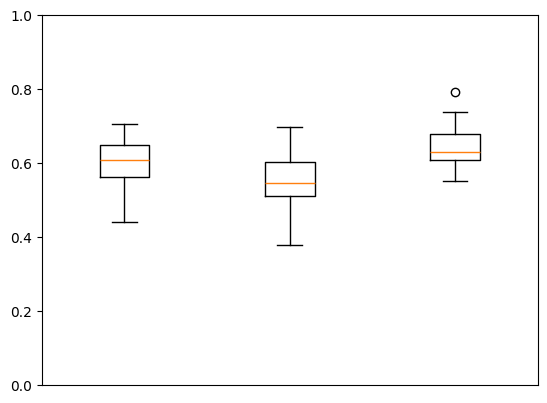

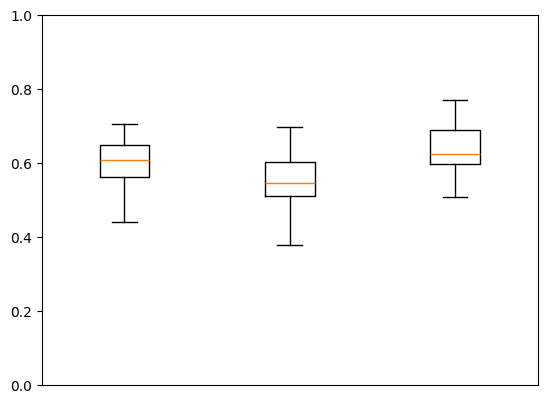

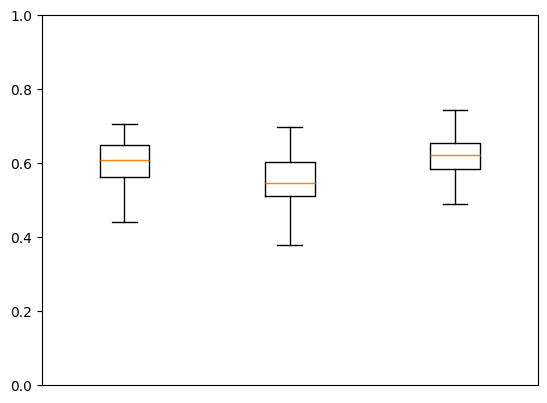

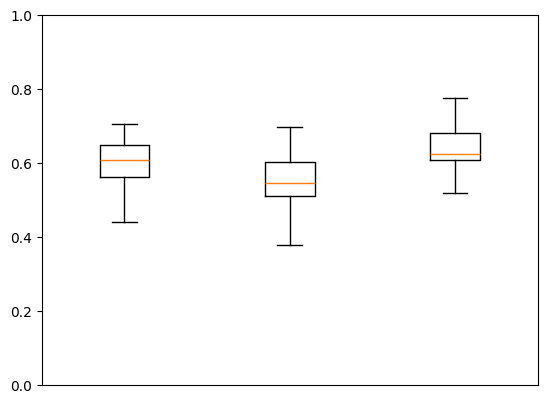

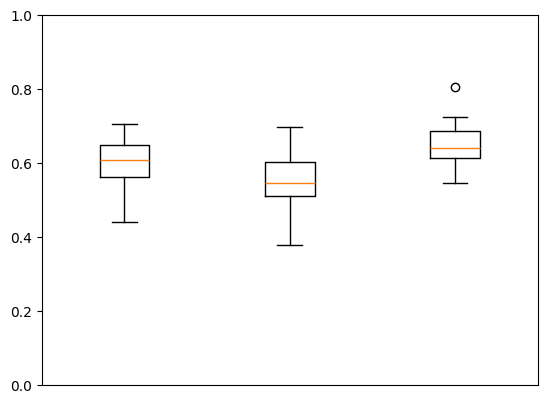

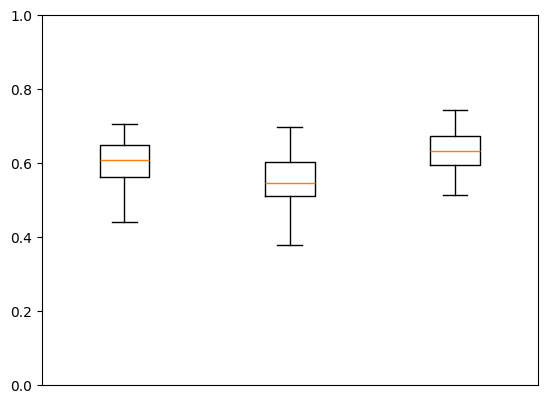

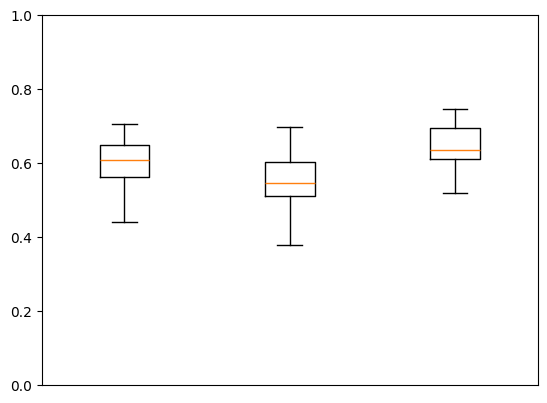

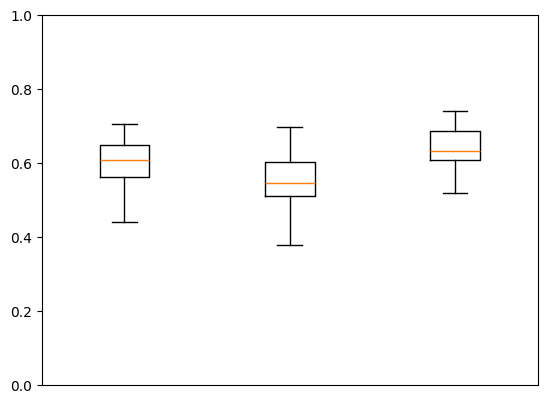

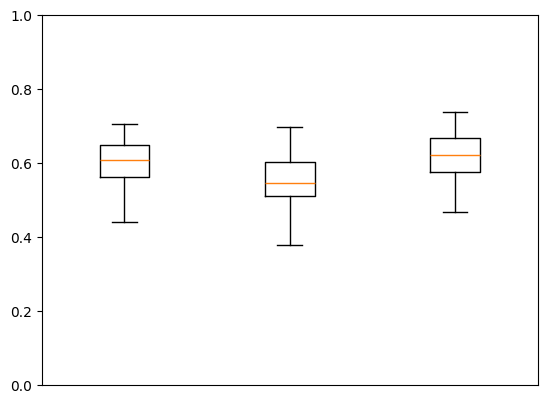

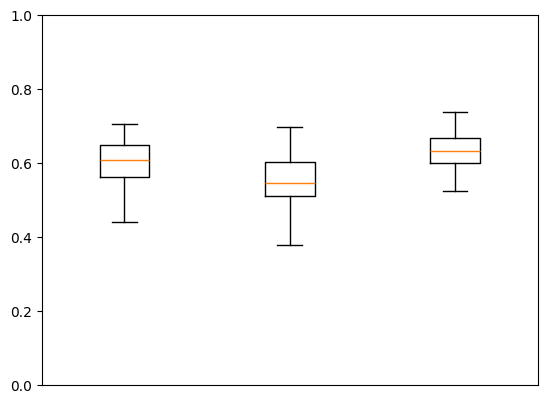

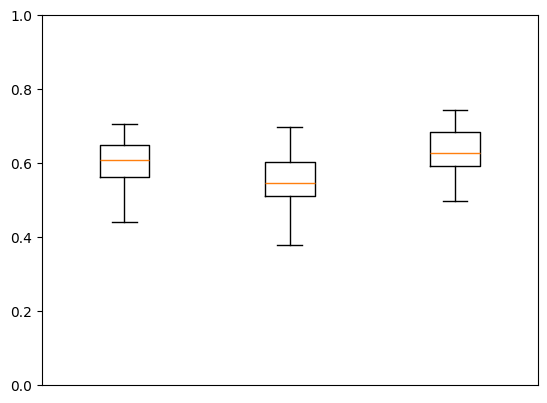

In [3]:
##
# This function will create a box plot for given VLM type accuracies for room classification.
# It will only use HTC cases and only VLM.
##
def testRoomClassifierAccuracy_LLM_hyb_VLM(llm_type):
    (llm_accuracies, 
     svc_accuracies, 
     cvm_accuracies, 
     llm_mean_time, 
     svc_mean_time, 
     cvm_mean_time, 
     storages_and_offices, 
     normal_mean_scores) = process_scene_files(llm_type, 
                                               fusion_type = ClassifierFusionType.LLM_THEN_CVM, 
                                               what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY)
    # should be 3 volumes -- one for LLM and one for SVC and one for CVM for accuracies compared to ground truth.
    number_of_dataset_volumes = 3

    # How many rooms were classified
    number_of_tests_per_dataset_volume = len(llm_accuracies)

    # We'll create an empty Numpy array and put the our SVC accuracies into there.
    dataset_test_results = np.zeros(shape=(number_of_dataset_volumes, number_of_tests_per_dataset_volume))
    #print(dataset_test_results.shape)

    dataset_test_results[0] = llm_accuracies
    dataset_test_results[1] = svc_accuracies
    dataset_test_results[2] = cvm_accuracies

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    print("normal_mean_scores = ", normal_mean_scores, " :: ", llm_type)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    ax.boxplot(dataset_test_results)
    plt.ylim(0.0, 1.0)
    #plt.show()

testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_0lbl_img_end_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_0lbl_img_middle_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_0lbl_img_middle")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_4lbl_img_end_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_4lbl_img_middle_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_4lbl_img_middle")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_6lbl_img_end_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_6lbl_img_middle_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_cot_6lbl_img_middle")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_0lbl_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_0lbl")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_4lbl_img_end_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_4lbl_img_middle_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_4lbl_img_middle")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_6lbl_img_end_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_6lbl_img_middle_nf4")
testRoomClassifierAccuracy_LLM_hyb_VLM("CHAMELEON_p_nocot_6lbl_img_middle")
testRoomClassifierAccuracy_LLM_hyb_VLM("MOONDREAM_p_cot_0lbl")
testRoomClassifierAccuracy_LLM_hyb_VLM("MOONDREAM_p_cot_4lbl")
testRoomClassifierAccuracy_LLM_hyb_VLM("MOONDREAM_p_cot_6lbl")
testRoomClassifierAccuracy_LLM_hyb_VLM("MOONDREAM_p_nocot_0lbl")
testRoomClassifierAccuracy_LLM_hyb_VLM("MOONDREAM_p_nocot_4lbl")
testRoomClassifierAccuracy_LLM_hyb_VLM("MOONDREAM_p_nocot_6lbl")

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import mean, median

def plot_my_data(dataset_test_results, normal_mean_results, labels, y_lim_bottom = 0.0):
    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results_T = np.transpose(dataset_test_results)
    
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    x_positions = np.arange(1, len(labels) + 1)  # Numeric positions for box plots
    ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(y_lim_bottom, 1.0)
    
    print(x_positions)
    # Line Plot (Secondary Axis)
    #ax1 = ax.twinx()  # Create secondary y-axis
    ax1 = ax
    ax1.scatter(x_positions, normal_mean_results, color='green', marker='o', label="Mean Value")  # Scatter instead of line
    
    plt.show()

    print("Median results: ", end='')
    for i in range(len(dataset_test_results)):
        print(f"{median(dataset_test_results[i]):.2f}", " ## ", end='')
        #print(median(dataset_test_results[i]), "##", end='')

    print("")
    
    print("Mean results: ", end='')
    for i in range(len(normal_mean_results)):
        print(f"{normal_mean_results[i]:.2f}", " ## ", end='')
        #print(normal_mean_results[i], "##", end='')

[1 2 3 4 5 6]


/tmp/ipykernel_32442/252424055.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)


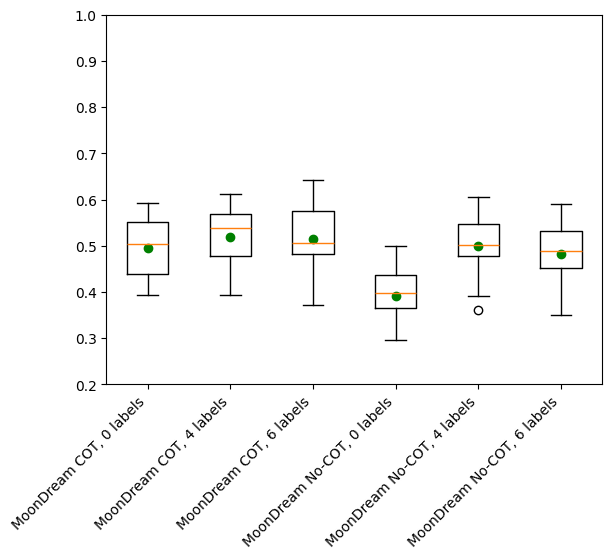

Median results: 0.50  ## 0.54  ## 0.51  ## 0.40  ## 0.50  ## 0.49  ## 
Mean results: 0.50  ## 0.52  ## 0.52  ## 0.39  ## 0.50  ## 0.48  ## 

In [11]:
#
# We'll go through the data sets in the following order:
#
# MOONDREAM_p_cot_0lbl 
# MOONDREAM_p_cot_4lbl
# MOONDREAM_p_cot_6lbl
# MOONDREAM_p_nocot_0lbl
# MOONDREAM_p_nocot_4lbl
# MOONDREAM_p_nocot_6lbl
#
# CHAMELEON_p_cot_0lbl_img_middle
# CHAMELEON_p_cot_4lbl_img_middle
# CHAMELEON_p_cot_6lbl_img_middle
# CHAMELEON_p_nocot_0lbl
# CHAMELEON_p_nocot_4lbl_img_middle
# CHAMELEON_p_nocot_6lbl_img_middle
#
# CHAMELEON_p_cot_0lbl_img_middle_nf4
# CHAMELEON_p_cot_4lbl_img_middle_nf4
# CHAMELEON_p_cot_6lbl_img_middle_nf4
# CHAMELEON_p_nocot_0lbl_nf4
# CHAMELEON_p_nocot_4lbl_img_middle_nf4
# CHAMELEON_p_nocot_6lbl_img_middle_nf4
#
# CHAMELEON_p_cot_0lbl_img_end_nf4
# CHAMELEON_p_cot_4lbl_img_end_nf4
# CHAMELEON_p_cot_6lbl_img_end_nf4
# CHAMELEON_p_nocot_4lbl_img_end_nf4
# CHAMELEON_p_nocot_6lbl_img_end_nf4
#

# We only need to get llm and svc accuracies and mean times the first time, because they will be the same in all other cases
(llm_accuracies, 
 svc_accuracies, 
 cvm_accuracies_m_c_0, 
 llm_mean_time, 
 svc_mean_time, 
 cvm_mean_time_m_c_0, 
 storages_and_offices_m_c_0, 
 normal_mean_scores_m_c_0) = process_scene_files("MOONDREAM_p_cot_0lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 0 labels
(_, _, cvm_accuracies_m_c_4, _, _, cvm_mean_time_m_c_4, storages_and_offices_m_c_4, normal_mean_scores_m_c_4) = process_scene_files("MOONDREAM_p_cot_4lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 4 labels
(_, _, cvm_accuracies_m_c_6, _, _, cvm_mean_time_m_c_6, storages_and_offices_m_c_6, normal_mean_scores_m_c_6) = process_scene_files("MOONDREAM_p_cot_6lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 6 labels
(_, _, cvm_accuracies_m_nc_0, _, _, cvm_mean_time_m_nc_0, storages_and_offices_m_nc_0, normal_mean_scores_m_nc_0) = process_scene_files("MOONDREAM_p_nocot_0lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 0 labels
(_, _, cvm_accuracies_m_nc_4, _, _, cvm_mean_time_m_nc_4, storages_and_offices_m_nc_4, normal_mean_scores_m_nc_4) = process_scene_files("MOONDREAM_p_nocot_4lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 4 labels
(_, _, cvm_accuracies_m_nc_6, _, _, cvm_mean_time_m_nc_6, storages_and_offices_m_nc_6, normal_mean_scores_m_nc_6) = process_scene_files("MOONDREAM_p_nocot_6lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 6 labels

# Moondream comparison
dataset_test_results = [cvm_accuracies_m_c_0, cvm_accuracies_m_c_4, cvm_accuracies_m_c_6, cvm_accuracies_m_nc_0, 
                        cvm_accuracies_m_nc_4, cvm_accuracies_m_nc_6]

normal_mean_results = [normal_mean_scores_m_c_0[2], normal_mean_scores_m_c_4[2], normal_mean_scores_m_c_6[2], normal_mean_scores_m_nc_0[2],
                       normal_mean_scores_m_nc_4[2], normal_mean_scores_m_nc_6[2]]

#print(dataset_test_results)

labels=['MoonDream COT, 0 labels', 'MoonDream COT, 4 labels', 'MoonDream COT, 6 labels', 'MoonDream No-COT, 0 labels', 
        'MoonDream No-COT, 4 labels', 'MoonDream No-COT, 6 labels']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.2)

[1 2 3 4 5 6]


/tmp/ipykernel_32442/252424055.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)


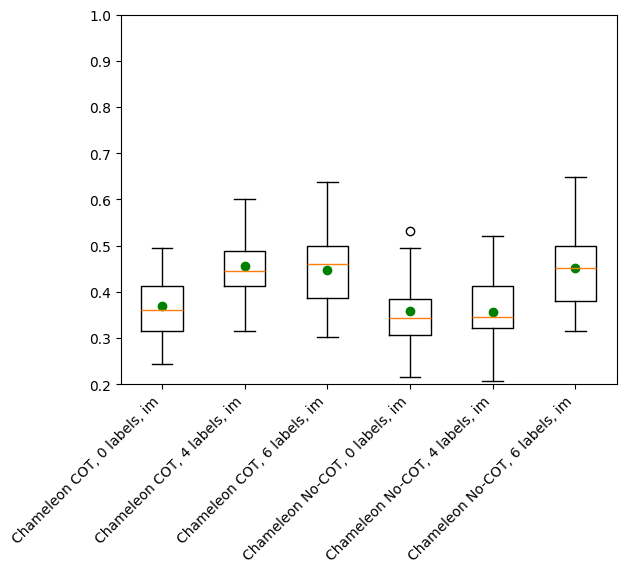

Median results: 0.36  ## 0.45  ## 0.46  ## 0.34  ## 0.34  ## 0.45  ## 
Mean results: 0.37  ## 0.46  ## 0.45  ## 0.36  ## 0.36  ## 0.45  ## 

In [12]:
#
# We'll go through the data sets in the following order:
#
# CHAMELEON_p_cot_0lbl_img_middle
# CHAMELEON_p_cot_4lbl_img_middle
# CHAMELEON_p_cot_6lbl_img_middle
# CHAMELEON_p_nocot_0lbl
# CHAMELEON_p_nocot_4lbl_img_middle
# CHAMELEON_p_nocot_6lbl_img_middle

# We only need to get llm and svc accuracies and mean times the first time, because they will be the same in all other cases
(llm_accuracies, 
 svc_accuracies, 
 cvm_accuracies_c_c_0_im, 
 llm_mean_time, 
 svc_mean_time, 
 cvm_mean_time_c_c_0_im, 
 storages_and_offices_c_c_0_im, 
 normal_mean_scores_c_c_0_im) = process_scene_files("CHAMELEON_p_cot_0lbl_img_middle", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 0 labels

(_, _, cvm_accuracies_c_c_4_im, 
 _, _, cvm_mean_time_c_c_4_im, 
 storages_and_offices_c_c_4_im, 
 normal_mean_scores_c_c_4_im) = process_scene_files("CHAMELEON_p_cot_4lbl_img_middle", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 4 labels

(_, _, cvm_accuracies_c_c_6_im, 
 _, _, cvm_mean_time_c_c_6_im, 
 storages_and_offices_c_c_6_im, 
 normal_mean_scores_c_c_6_im) = process_scene_files("CHAMELEON_p_cot_6lbl_img_middle", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 6 labels

(_, _, cvm_accuracies_c_nc_0_im, 
 _, _, cvm_mean_time_c_nc_0_im, 
 storages_and_offices_c_nc_0_im, 
 normal_mean_scores_c_nc_0_im) = process_scene_files("CHAMELEON_p_nocot_0lbl", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 0 labels

(_, _, cvm_accuracies_c_nc_4_im, 
 _, _, cvm_mean_time_c_nc_4_im, 
 storages_and_offices_c_nc_4_im, 
 normal_mean_scores_c_nc_4_im) = process_scene_files("CHAMELEON_p_nocot_4lbl_img_middle", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 4 labels

(_, _, cvm_accuracies_c_nc_6_im, 
 _, _, cvm_mean_time_c_nc_6_im, 
 storages_and_offices_c_nc_6_im, 
 normal_mean_scores_c_nc_6_im) = process_scene_files("CHAMELEON_p_nocot_6lbl_img_middle", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 6 labels

# Moondream comparison
dataset_test_results = [cvm_accuracies_c_c_0_im, cvm_accuracies_c_c_4_im, cvm_accuracies_c_c_6_im, cvm_accuracies_c_nc_0_im, 
                        cvm_accuracies_c_nc_4_im, cvm_accuracies_c_nc_6_im]

normal_mean_results = [normal_mean_scores_c_c_0_im[2], normal_mean_scores_c_c_4_im[2], normal_mean_scores_c_c_6_im[2], normal_mean_scores_c_nc_0_im[2],
                       normal_mean_scores_c_nc_4_im[2], normal_mean_scores_c_nc_6_im[2]]

#print(dataset_test_results)

labels=['Chameleon COT, 0 labels, im', 'Chameleon COT, 4 labels, im', 'Chameleon COT, 6 labels, im', 'Chameleon No-COT, 0 labels, im', 
        'Chameleon No-COT, 4 labels, im', 'Chameleon No-COT, 6 labels, im']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.2)

[1 2 3 4 5 6]


/tmp/ipykernel_32442/252424055.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)


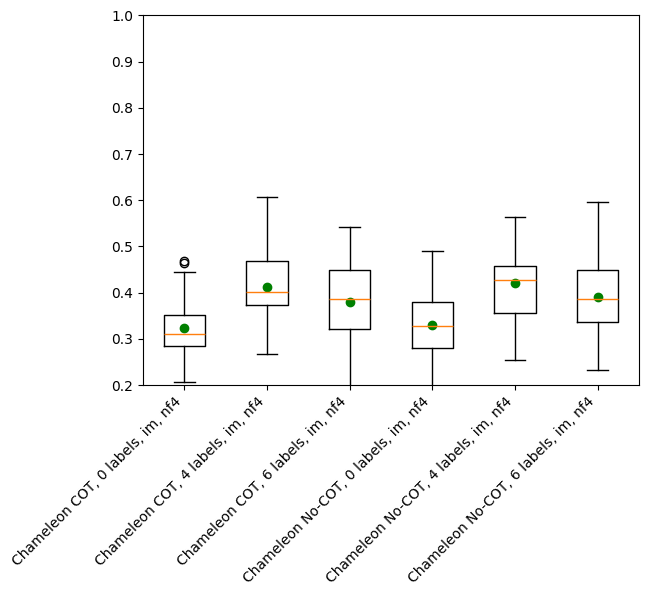

Median results: 0.31  ## 0.40  ## 0.39  ## 0.33  ## 0.43  ## 0.39  ## 
Mean results: 0.32  ## 0.41  ## 0.38  ## 0.33  ## 0.42  ## 0.39  ## 

In [13]:
#
# We'll go through the data sets in the following order:
# CHAMELEON_p_cot_0lbl_img_middle_nf4
# CHAMELEON_p_cot_4lbl_img_middle_nf4
# CHAMELEON_p_cot_6lbl_img_middle_nf4
# CHAMELEON_p_nocot_0lbl_nf4
# CHAMELEON_p_nocot_4lbl_img_middle_nf4
# CHAMELEON_p_nocot_6lbl_img_middle_nf4

# We only need to get llm and svc accuracies and mean times the first time, because they will be the same in all other cases
(llm_accuracies, 
 svc_accuracies, 
 cvm_accuracies_c_c_0_im_nf4, 
 llm_mean_time, 
 svc_mean_time, 
 cvm_mean_time_c_c_0_im_nf4, 
 storages_and_offices_c_c_0_im_nf4, 
 normal_mean_scores_c_c_0_im_nf4) = process_scene_files("CHAMELEON_p_cot_0lbl_img_middle_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 0 labels

(_, _, cvm_accuracies_c_c_4_im_nf4, 
 _, _, cvm_mean_time_c_c_4_im_nf4, 
 storages_and_offices_c_c_4_im_nf4, 
 normal_mean_scores_c_c_4_im_nf4) = process_scene_files("CHAMELEON_p_cot_4lbl_img_middle_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 4 labels

(_, _, cvm_accuracies_c_c_6_im_nf4, 
 _, _, cvm_mean_time_c_c_6_im_nf4, 
 storages_and_offices_c_c_6_im_nf4, 
 normal_mean_scores_c_c_6_im_nf4) = process_scene_files("CHAMELEON_p_cot_6lbl_img_middle_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 6 labels

(_, _, cvm_accuracies_c_nc_0_im_nf4, 
 _, _, cvm_mean_time_c_nc_0_im_nf4, 
 storages_and_offices_c_nc_0_im_nf4, 
 normal_mean_scores_c_nc_0_im_nf4) = process_scene_files("CHAMELEON_p_nocot_0lbl_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 0 labels

(_, _, cvm_accuracies_c_nc_4_im_nf4, 
 _, _, cvm_mean_time_c_nc_4_im_nf4, 
 storages_and_offices_c_nc_4_im_nf4, 
 normal_mean_scores_c_nc_4_im_nf4) = process_scene_files("CHAMELEON_p_nocot_4lbl_img_middle_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 4 labels

(_, _, cvm_accuracies_c_nc_6_im_nf4, 
 _, _, cvm_mean_time_c_nc_6_im_nf4, 
 storages_and_offices_c_nc_6_im_nf4, 
 normal_mean_scores_c_nc_6_im_nf4) = process_scene_files("CHAMELEON_p_nocot_6lbl_img_middle_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 6 labels

# Moondream comparison
dataset_test_results = [cvm_accuracies_c_c_0_im_nf4, cvm_accuracies_c_c_4_im_nf4, cvm_accuracies_c_c_6_im_nf4, cvm_accuracies_c_nc_0_im_nf4, 
                        cvm_accuracies_c_nc_4_im_nf4, cvm_accuracies_c_nc_6_im_nf4]

normal_mean_results = [normal_mean_scores_c_c_0_im_nf4[2], normal_mean_scores_c_c_4_im_nf4[2], normal_mean_scores_c_c_6_im_nf4[2], normal_mean_scores_c_nc_0_im_nf4[2],
                       normal_mean_scores_c_nc_4_im_nf4[2], normal_mean_scores_c_nc_6_im_nf4[2]]

#print(dataset_test_results)

labels=['Chameleon COT, 0 labels, im, nf4', 'Chameleon COT, 4 labels, im, nf4', 'Chameleon COT, 6 labels, im, nf4', 'Chameleon No-COT, 0 labels, im, nf4', 
        'Chameleon No-COT, 4 labels, im, nf4', 'Chameleon No-COT, 6 labels, im, nf4']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.2)

[1 2 3 4 5 6]


/tmp/ipykernel_32442/252424055.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)


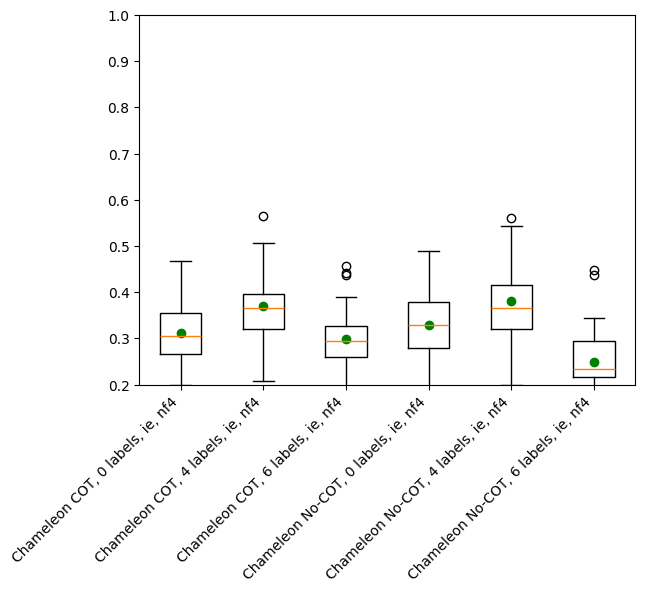

Median results: 0.30  ## 0.37  ## 0.29  ## 0.33  ## 0.37  ## 0.23  ## 
Mean results: 0.31  ## 0.37  ## 0.30  ## 0.33  ## 0.38  ## 0.25  ## 

In [14]:
#
# We'll go through the data sets in the following order:
# CHAMELEON_p_cot_0lbl_img_end_nf4
# CHAMELEON_p_cot_4lbl_img_end_nf4
# CHAMELEON_p_cot_6lbl_img_end_nf4
# CHAMELEON_p_nocot_0lbl_nf4
# CHAMELEON_p_nocot_4lbl_img_end_nf4
# CHAMELEON_p_nocot_6lbl_img_end_nf4

# We only need to get llm and svc accuracies and mean times the first time, because they will be the same in all other cases
(llm_accuracies, 
 svc_accuracies, 
 cvm_accuracies_c_c_0_ie_nf4, 
 llm_mean_time, 
 svc_mean_time, 
 cvm_mean_time_c_c_0_ie_nf4, 
 storages_and_offices_c_c_0_ie_nf4, 
 normal_mean_scores_c_c_0_ie_nf4) = process_scene_files("CHAMELEON_p_cot_0lbl_img_end_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 0 labels

(_, _, cvm_accuracies_c_c_4_ie_nf4, 
 _, _, cvm_mean_time_c_c_4_ie_nf4, 
 storages_and_offices_c_c_4_ie_nf4, 
 normal_mean_scores_c_c_4_ie_nf4) = process_scene_files("CHAMELEON_p_cot_4lbl_img_end_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 4 labels

(_, _, cvm_accuracies_c_c_6_ie_nf4, 
 _, _, cvm_mean_time_c_c_6_ie_nf4, 
 storages_and_offices_c_c_6_ie_nf4, 
 normal_mean_scores_c_c_6_ie_nf4) = process_scene_files("CHAMELEON_p_cot_6lbl_img_end_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, COT, 6 labels

(_, _, cvm_accuracies_c_nc_0_ie_nf4, 
 _, _, cvm_mean_time_c_nc_0_ie_nf4, 
 storages_and_offices_c_nc_0_ie_nf4, 
 normal_mean_scores_c_nc_0_ie_nf4) = process_scene_files("CHAMELEON_p_nocot_0lbl_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 0 labels

(_, _, cvm_accuracies_c_nc_4_ie_nf4, 
 _, _, cvm_mean_time_c_nc_4_ie_nf4, 
 storages_and_offices_c_nc_4_ie_nf4, 
 normal_mean_scores_c_nc_4_ie_nf4) = process_scene_files("CHAMELEON_p_nocot_4lbl_img_end_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 4 labels

(_, _, cvm_accuracies_c_nc_6_ie_nf4, 
 _, _, cvm_mean_time_c_nc_6_ie_nf4, 
 storages_and_offices_c_nc_6_ie_nf4, 
 normal_mean_scores_c_nc_6_ie_nf4) = process_scene_files("CHAMELEON_p_nocot_6lbl_img_end_nf4", fusion_type = ClassifierFusionType.NO_FUSION, 
        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY) # VLM results only Moondream, no COT, 6 labels

# Moondream comparison
dataset_test_results = [cvm_accuracies_c_c_0_ie_nf4, cvm_accuracies_c_c_4_ie_nf4, cvm_accuracies_c_c_6_ie_nf4, cvm_accuracies_c_nc_0_ie_nf4, 
                        cvm_accuracies_c_nc_4_ie_nf4, cvm_accuracies_c_nc_6_ie_nf4]

normal_mean_results = [normal_mean_scores_c_c_0_ie_nf4[2], normal_mean_scores_c_c_4_ie_nf4[2], normal_mean_scores_c_c_6_ie_nf4[2], normal_mean_scores_c_nc_0_ie_nf4[2],
                       normal_mean_scores_c_nc_4_ie_nf4[2], normal_mean_scores_c_nc_6_ie_nf4[2]]

#print(dataset_test_results)

labels=['Chameleon COT, 0 labels, ie, nf4', 'Chameleon COT, 4 labels, ie, nf4', 'Chameleon COT, 6 labels, ie, nf4', 'Chameleon No-COT, 0 labels, ie, nf4', 
        'Chameleon No-COT, 4 labels, ie, nf4', 'Chameleon No-COT, 6 labels, ie, nf4']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.2)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import mean, median

def plot_my_data(dataset_test_results, normal_mean_results, labels, y_lim_bottom = 0.0):
    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results_T = np.transpose(dataset_test_results)
    
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    x_positions = np.arange(1, len(labels) + 1)  # Numeric positions for box plots
    ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(y_lim_bottom, 1.0)
    
    print(x_positions)
    # Line Plot (Secondary Axis)
    #ax1 = ax.twinx()  # Create secondary y-axis
    ax1 = ax
    ax1.scatter(x_positions, normal_mean_results, color='green', marker='o', label="Mean Value")  # Scatter instead of line
    
    plt.show()

    print("Median results: ", end='')
    for i in range(len(dataset_test_results)):
        print(median(dataset_test_results[i]), "##", end='')

    print("")
    
    print("Mean results: ", end='')
    for i in range(len(normal_mean_results)):
        print(normal_mean_results[i], "##", end='')

(llm_accuracies_fair, svc_accuracies, cvm_accuracies_cham, llm_mean_time, svc_mean_time, cvm_mean_time_cham, storages_and_offices_cham, normal_mean_scores_cham) = process_scene_files("CHAMELEON")
(_, _, cvm_accuracies_cham_fp, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp, normal_mean_scores_cham_fp) = process_scene_files("CHAMELEON_full_prompt")
(_, _, cvm_accuracies_cham_4l, llm_mean_time, svc_mean_time, cvm_mean_time_cham_4l, storages_and_offices_cham_4l, normal_mean_scores_cham_4l) = process_scene_files("CHAMELEON_4labels")
(_, _, cvm_accuracies_cham_fx, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fx, storages_and_offices_cham_fx, normal_mean_scores_cham_fx) = process_scene_files("CHAMELEON_fixed")
(_, _, cvm_accuracies_md_fp, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp, storages_and_offices_md_fp, normal_mean_scores_md_fp) = process_scene_files("MOONDREAM_full_prompt")
(_, _, cvm_accuracies_md_ow, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow, storages_and_offices_md_ow, normal_mean_scores_md_ow) = process_scene_files("MOONDREAM_one_word")

(_, _, cvm_accuracies_cham_fp_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp_llmtcvm, storages_and_offices_cham_fp_llmtcvm, normal_mean_scores_cham_fp_llmtcvm) = process_scene_files("CHAMELEON_full_prompt", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_cham_4l_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_4l_llmtcvm, storages_and_offices_cham_4l_llmtcvm, normal_mean_scores_cham_4l_llmtcvm) = process_scene_files("CHAMELEON_4labels", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_cham_fx_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fx_llmtcvm, storages_and_offices_cham_fx_llmtcvm, normal_mean_scores_cham_fx_llmtcvm) = process_scene_files("CHAMELEON_fixed", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_md_fp_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp_llmtcvm, storages_and_offices_md_fp_llmtcvm, normal_mean_scores_md_fp_llmtcvm) = process_scene_files("MOONDREAM_full_prompt", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_md_ow_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow_llmtcvm, storages_and_offices_md_ow_llmtcvm, normal_mean_scores_md_ow_llmtcvm) = process_scene_files("MOONDREAM_one_word", ClassifierFusionType.LLM_THEN_CVM)

(_, _, cvm_accuracies_cham_fp_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp_cvmtllm, storages_and_offices_cham_fp_cvmtllm, normal_mean_scores_cham_fp_cvmtllm) = process_scene_files("CHAMELEON_full_prompt", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_cham_4l_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_4l_cvmtllm, storages_and_offices_cham_4l_cvmtllm, normal_mean_scores_cham_4l_cvmtllm) = process_scene_files("CHAMELEON_4labels", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_cham_fx_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fx_cvmtllm, storages_and_offices_cham_fx_cvmtllm, normal_mean_scores_cham_fx_cvmtllm) = process_scene_files("CHAMELEON_fixed", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_md_fp_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp_cvmtllm, storages_and_offices_md_fp_cvmtllm, normal_mean_scores_md_fp_cvmtllm) = process_scene_files("MOONDREAM_full_prompt", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_md_ow_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow_cvmtllm, storages_and_offices_md_ow_cvmtllm, normal_mean_scores_md_ow_cvmtllm) = process_scene_files("MOONDREAM_one_word", ClassifierFusionType.CVM_THEN_LLM)
(llm_accuracies, _, _, llm_mean_time, svc_mean_time, _, _, normal_mean_scores_llama) = process_scene_files("LLAMA")

(_, _, cvm_accuracies_cham_fp_fair, _, _, _, _, normal_mean_scores_cham_fp_fair) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_cham_4l_fair, _, _, _, _, normal_mean_scores_cham_4l_fair) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_cham_fx_fair, _, _, _, _, normal_mean_scores_cham_fx_fair) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_md_fp_fair, _, _, _, _, normal_mean_scores_md_fp_fair) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_md_ow_fair, _, _, _, _, normal_mean_scores_md_ow_fair) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)

(_, _, cvm_accuracies_cham_fp_hard, _, _, _, _, normal_mean_scores_cham_fp_hard) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_4l_hard, _, _, _, _, normal_mean_scores_cham_4l_hard) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_fx_hard, _, _, _, _, normal_mean_scores_cham_fx_hard) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_fp_hard, _, _, _, _, normal_mean_scores_md_fp_hard) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_ow_hard, _, _, _, _, normal_mean_scores_md_ow_hard) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)

(_, _, cvm_accuracies_cham_fp_guess, _, _, _, _, normal_mean_scores_cham_fp_guess) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_4l_guess, _, _, _, _, normal_mean_scores_cham_4l_guess) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_fx_guess, _, _, _, _, normal_mean_scores_cham_fx_guess) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_fp_guess, _, _, _, _, normal_mean_scores_md_fp_guess) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_ow_guess, _, _, _, _, normal_mean_scores_md_ow_guess) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)

(_, _, cvm_accuracies_cham_fp_llm_fail, _, _, _, _, normal_mean_scores_cham_fp_llm_fail) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_cham_4l_llm_fail, _, _, _, _, normal_mean_scores_cham_4l_llm_fail) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_cham_fx_llm_fail, _, _, _, _, normal_mean_scores_cham_fx_llm_fail) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_md_fp_llm_fail, _, _, _, _, normal_mean_scores_md_fp_llm_fail) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_md_ow_llm_fail, _, _, _, _, normal_mean_scores_md_ow_llm_fail) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)

(llm_accuracies_htc_guessed, _, _, _, _, _, _, normal_mean_scores_htc_guessed) = process_scene_files("CHAMELEON", what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM)

# should be two volumes -- one for LLM and one for SVC for accuracies compared to ground truth.
#number_of_dataset_volumes = 11

# How many rooms were classified
#number_of_tests_per_dataset_volume = len(svc_accuracies)
#print(str(len(svc_accuracies)) + " " + str(len(cvm_accuracies_cham)) + " " + str(len(cvm_accuracies_cham_fp)) + " " + str(len(cvm_accuracies_md_fp)) + " " + str(len(cvm_accuracies_md_ow)))
#print(str(storages_and_offices_cham) + " " + str(storages_and_offices_cham))

# We'll create an empty Numpy array and put the our SVC accuracies into there.
#dataset_test_results = np.zeros(shape=(number_of_dataset_volumes, number_of_tests_per_dataset_volume))
#print(dataset_test_results.shape)

#    dataset_test_results[0] = cvm_accuracies_cham
#    dataset_test_results[1] = cvm_accuracies_cham_fp
#    dataset_test_results[2] = cvm_accuracies_md_fp
#    dataset_test_results[3] = cvm_accuracies_md_ow
#    dataset_test_results[4] = svc_accuracies

#dataset_test_results = [cvm_accuracies_cham, cvm_accuracies_cham_fp, cvm_accuracies_md_fp, cvm_accuracies_md_ow, svc_accuracies]
dataset_test_results = [cvm_accuracies_cham_fp, cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp, cvm_accuracies_md_ow, 
                        svc_accuracies, 
                        cvm_accuracies_cham_fp_cvmtllm, cvm_accuracies_cham_4l_cvmtllm, cvm_accuracies_cham_fx_cvmtllm, cvm_accuracies_md_fp_cvmtllm, cvm_accuracies_md_ow_cvmtllm, 
                        cvm_accuracies_cham_fp_llmtcvm, cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm, cvm_accuracies_md_ow_llmtcvm, 
                        llm_accuracies, 
                        llm_accuracies_fair, 
                        llm_accuracies_htc_guessed,
                        cvm_accuracies_cham_fp_fair, cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, cvm_accuracies_md_ow_fair, 
                        cvm_accuracies_cham_fp_hard, cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, cvm_accuracies_md_ow_hard, 
                        cvm_accuracies_cham_fp_guess, cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess, cvm_accuracies_md_fp_guess, cvm_accuracies_md_ow_guess, 
                        cvm_accuracies_cham_fp_llm_fail, cvm_accuracies_cham_4l_llm_fail, cvm_accuracies_cham_fx_llm_fail, cvm_accuracies_md_fp_llm_fail, cvm_accuracies_md_ow_llm_fail]

normal_mean_results = [normal_mean_scores_cham_fp[2], normal_mean_scores_cham_4l[2], normal_mean_scores_cham_fx[2], normal_mean_scores_md_fp[2], normal_mean_scores_md_ow_cvmtllm[2],
                       normal_mean_scores_cham[1], 
                       normal_mean_scores_cham_fp_cvmtllm[2], normal_mean_scores_cham_4l_cvmtllm[2], normal_mean_scores_cham_fx_cvmtllm[2], normal_mean_scores_md_fp_cvmtllm[2], normal_mean_scores_md_ow_cvmtllm[2],
                       normal_mean_scores_cham_fp_llmtcvm[2], normal_mean_scores_cham_4l_llmtcvm[2], normal_mean_scores_cham_fx_llmtcvm[2], normal_mean_scores_md_fp_llmtcvm[2], normal_mean_scores_md_ow_llmtcvm[2],
                       normal_mean_scores_llama[0],
                       normal_mean_scores_cham[0],
                       normal_mean_scores_htc_guessed[0],
                       normal_mean_scores_cham_fp_fair[2], normal_mean_scores_cham_4l_fair[2], normal_mean_scores_cham_fx_fair[2], normal_mean_scores_md_fp_fair[2], normal_mean_scores_md_ow_fair[2],
                       normal_mean_scores_cham_fp_hard[2], normal_mean_scores_cham_4l_hard[2], normal_mean_scores_cham_fx_hard[2], normal_mean_scores_md_fp_hard[2], normal_mean_scores_md_ow_hard[2],
                       normal_mean_scores_cham_fp_guess[2], normal_mean_scores_cham_4l_guess[2], normal_mean_scores_cham_fx_guess[2], normal_mean_scores_md_fp_guess[2], normal_mean_scores_md_ow_guess[2],
                       normal_mean_scores_cham_fp_llm_fail[2], normal_mean_scores_cham_4l_llm_fail[2], normal_mean_scores_cham_fx_llm_fail[2], normal_mean_scores_md_fp_llm_fail[2], normal_mean_scores_md_ow_llm_fail[2]]

##print(dataset_test_results)
#fig, ax = plt.subplots()
#ax.axes.get_xaxis().set_visible(False)
##ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
##if (model_type == ModelType.HYBRID_AT_12):
##    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
##elif (model_type == ModelType.HYBRID_AT_18):
##    ax.set_title("Scannet - Hybridized with AI2-THOR data")
##ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
labels=['Chameleon', 'Chameleon-4l', 'Chameleon_fx', 'MoonDream fp', 'MoonDream ow', 
        'SVC', 
        'Chameleon_cl', 'Chameleon_cl-4l', 'Chameleon_cl_fx', 'MoonDream fp_cl', 'MoonDream ow_cl', 
        'Chameleon_lc', 'Chameleon_lc-4l', 'Chameleon_lc_fx', 'MoonDream fp_lc', 'MoonDream ow_lc', 
        'LLM', 
        'LLM-fair', 
        'LLM-HTC-guessed',
        'Chameleon_fair', 'Chameleon_fair-4l', 'Chameleon_fair_fx', 'MoonDream fp_fair', 'MoonDream ow_fair', 
        'Chameleon_hard', 'Chameleon_hard-4l', 'Chameleon_hard_fx', 'MoonDream fp_hard', 'MoonDream ow_hard', 
        'Chameleon_guess', 'Chameleon_guess-4l', 'Chameleon_guess_fx', 'MoonDream fp_guess', 'MoonDream ow_guess', 
        'Chameleon_llm_fail', 'Chameleon_llm_fail-4l', 'Chameleon_llm_fail_fx', 'MoonDream fp_llm_fail', 'MoonDream ow_llm_fail']

plot_my_data(dataset_test_results, normal_mean_results, labels)

print("cvm_mean_time_cham = " + str(cvm_mean_time_cham))
print("cvm_mean_time_cham_fp = " + str(cvm_mean_time_cham_fp))
print("cvm_mean_time_md_fp = " + str(cvm_mean_time_md_fp))
print("cvm_mean_time_md_ow = " + str(cvm_mean_time_md_ow))
print("svc_mean_time = " + str(svc_mean_time))


# Interim chart
dataset_test_results = [cvm_accuracies_cham, cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp, 
                        cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm, 
                        llm_accuracies, 
                        llm_accuracies_fair, 
                        llm_accuracies_htc_guessed,
                        cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, 
                        cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, 
                        cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess, cvm_accuracies_md_fp_guess]

normal_mean_results = [normal_mean_scores_cham[2], normal_mean_scores_cham_4l[2], normal_mean_scores_cham_fx[2], normal_mean_scores_md_fp[2],
                       normal_mean_scores_cham_4l_llmtcvm[2], normal_mean_scores_cham_fx_llmtcvm[2], normal_mean_scores_md_fp_llmtcvm[2],
                       normal_mean_scores_llama[0],
                       normal_mean_scores_cham[0],
                       normal_mean_scores_htc_guessed[0],
                       normal_mean_scores_cham_4l_fair[2], normal_mean_scores_cham_fx_fair[2], normal_mean_scores_md_fp_fair[2],
                       normal_mean_scores_cham_4l_hard[2], normal_mean_scores_cham_fx_hard[2], normal_mean_scores_md_fp_hard[2],
                       normal_mean_scores_cham_4l_guess[2], normal_mean_scores_cham_fx_guess[2], normal_mean_scores_md_fp_guess[2]]

labels=['Chameleon', 'Chameleon_4l', 'Chameleon_fx', 'MoonDream fp',
        'Chameleon_lc_4l', 'Chameleon_lc_fx', 'MoonDream fp_lc', 
        'LLM', 
        'LLM-fair', 
        'LLM-HTC-guessed',
        'Chameleon_fair_4l', 'Chameleon_fair_fx', 'MoonDream fp_fair', 
        'Chameleon_hard_4l', 'Chameleon_hard_fx', 'MoonDream fp_hard',  
        'Chameleon_guess_4l', 'Chameleon_guess_fx', 'MoonDream fp_guess']

plot_my_data(dataset_test_results, normal_mean_results, labels)
print("Median vals: " + str(median(llm_accuracies)) 
      + " ## " + str(median(llm_accuracies_fair)) 
      + " ## " + str(median(llm_accuracies_htc_guessed)) 
      + " ## " + str(median(cvm_accuracies_cham_4l_llmtcvm)) 
      + " ## " + str(median(cvm_accuracies_cham_fx_llmtcvm)) 
      + " ## " + str(median(cvm_accuracies_md_fp_llmtcvm)))

# CVM and LLM comparison
dataset_test_results = [llm_accuracies, cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, 
                        cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp]

normal_mean_results = [normal_mean_scores_llama[0], normal_mean_scores_cham_4l_fair[2], normal_mean_scores_cham_fx_fair[2], normal_mean_scores_md_fp_fair[2],
                       normal_mean_scores_cham_4l[2], normal_mean_scores_cham_fx[2], normal_mean_scores_md_fp[2]]

#print(dataset_test_results)

labels=['Llama3 (no HTC)', 'Chameleon, 4 labels (no HTC)', 'Chameleon, 6 labels (no HTC)', 'MoonDream, 6 labels (no HTC)', 
        'Chameleon, 4 labels (with HTC)', 'Chameleon, 6 labels (with HTC)', 'MoonDream, 6 labels (with HTC)']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.2)

# Hard part analysis
dataset_test_results = [cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, 
                        cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess]

normal_mean_results = [normal_mean_scores_cham_4l_hard[2], normal_mean_scores_cham_fx_hard[2], normal_mean_scores_md_fp_hard[2],
                       normal_mean_scores_cham_4l_guess[2], normal_mean_scores_cham_fx_guess[2]]

#print(dataset_test_results)

labels=['Chameleon, 4 labels (HTC only)', 'Chameleon, 6 labels (HTC only)', 'MoonDream, 6 labels (HTC only)',  
        'Random Guess, 4 labels', 'Random Guess, 6 labels']

plot_my_data(dataset_test_results, normal_mean_results, labels)

# Fused results
dataset_test_results = [llm_accuracies, 
                        llm_accuracies_fair,
                        llm_accuracies_htc_guessed,
                        cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm]

normal_mean_results = [normal_mean_scores_llama[0],
                       normal_mean_scores_cham[0],
                       normal_mean_scores_htc_guessed[0],
                       normal_mean_scores_cham_4l_llmtcvm[2], normal_mean_scores_cham_fx_llmtcvm[2], normal_mean_scores_md_fp_llmtcvm[2]]

labels=['Llama3 (no HTC)', 
        'Llama3 (HTC discounted)', 
        'Llama3 (HTC guessed)', 
        'Llama3 + Chameleon, 4 labels (with HTC)', 'Llama3 + Chameleon, 6 labels (with HTC)', 'Llama3 + MoonDream (with HTC)']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.3)

#print("Median vals: " + str(median(llm_accuracies)) + " ## " + str(median(llm_accuracies_fair)) + " ## " + str(median(llm_accuracies_htc_guessed)) + " ## " + str(median(cvm_accuracies_cham_4l_llmtcvm)) + " ## " + str(median(cvm_accuracies_cham_fx_llmtcvm)) + " ## " + str(median(cvm_accuracies_md_fp_llmtcvm)))


#testAllRoomClassifiersAccuracy()

ZeroDivisionError: division by zero

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


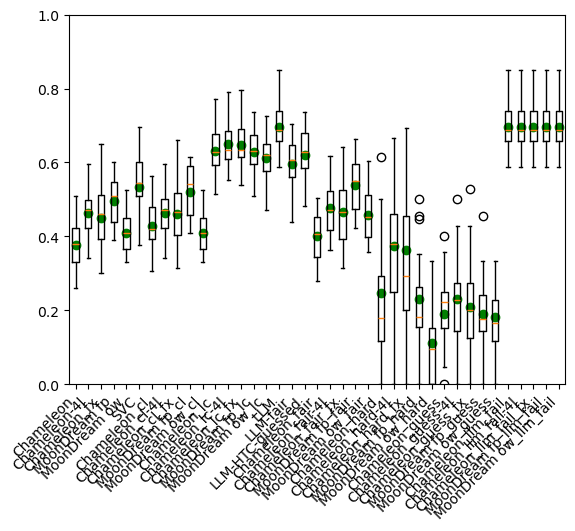

Median results: 0.3804878048780488 ##0.472 ##0.46195652173913043 ##0.5098039215686274 ##0.4105263157894737 ##0.544 ##0.42063492063492064 ##0.472 ##0.4673913043478261 ##0.5423728813559322 ##0.4105263157894737 ##0.6276595744680851 ##0.6349206349206349 ##0.6349206349206349 ##0.631578947368421 ##0.6216216216216216 ##0.6871794871794872 ##0.60625 ##0.6271186440677966 ##0.4068627450980392 ##0.47058823529411764 ##0.4666666666666667 ##0.5490196078431373 ##0.4527027027027027 ##0.17857142857142858 ##0.3793103448275862 ##0.29411764705882354 ##0.18181818181818182 ##0.09523809523809523 ##0.2222222222222222 ##0.22807017543859648 ##0.2 ##0.17647058823529413 ##0.16666666666666666 ##0.6871794871794872 ##0.6871794871794872 ##0.6871794871794872 ##0.6871794871794872 ##0.6871794871794872 ##
Mean results: 0.3778563015312132 ##0.46219081272084805 ##0.45111896348645464 ##0.49517078916372204 ##0.4091872791519435 ##0.5347467608951708 ##0.42803297997644285 ##0.4633686690223793 ##0.4600706713780919 ##0.52108362779

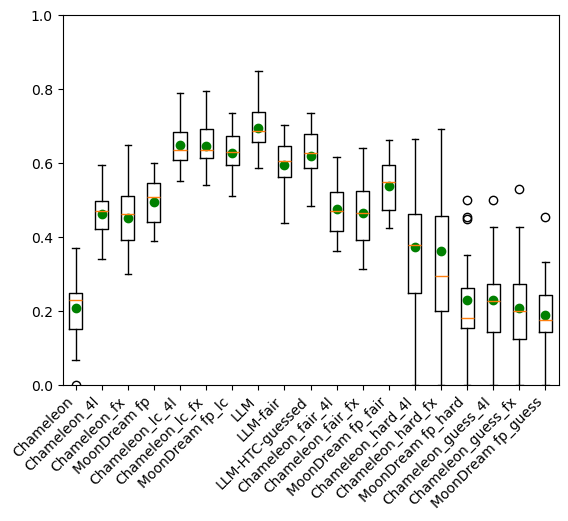

Median results: 0.22905027932960895 ##0.472 ##0.46195652173913043 ##0.5098039215686274 ##0.6349206349206349 ##0.6349206349206349 ##0.631578947368421 ##0.6871794871794872 ##0.60625 ##0.6271186440677966 ##0.47058823529411764 ##0.4666666666666667 ##0.5490196078431373 ##0.3793103448275862 ##0.29411764705882354 ##0.18181818181818182 ##0.22807017543859648 ##0.2 ##0.17647058823529413 ##
Mean results: 0.20730270906949352 ##0.46219081272084805 ##0.45111896348645464 ##0.49517078916372204 ##0.6492343934040047 ##0.6478209658421673 ##0.6289752650176679 ##0.6952459466886507 ##0.5959952885747939 ##0.620494699646643 ##0.4770541357515801 ##0.46578730420445175 ##0.5391591096455071 ##0.37293729372937295 ##0.36303630363036304 ##0.23102310231023102 ##0.23102310231023102 ##0.20957095709570958 ##0.18976897689768976 ##Median vals: 0.6871794871794872 ## 0.60625 ## 0.6271186440677966 ## 0.6349206349206349 ## 0.6349206349206349 ## 0.631578947368421
[1 2 3 4 5 6 7]


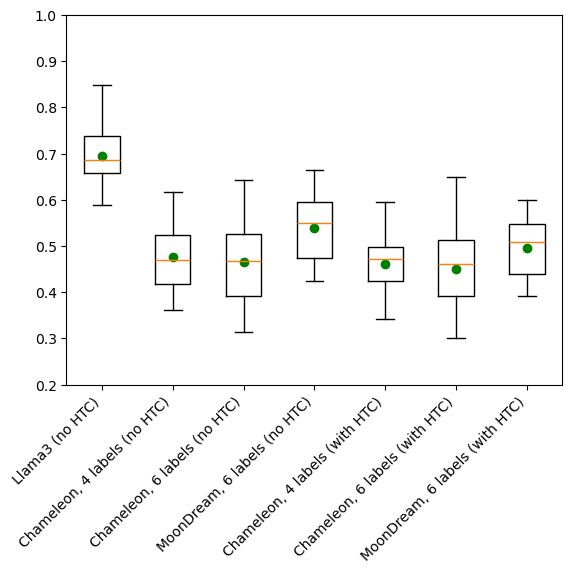

Median results: 0.6871794871794872 ##0.47058823529411764 ##0.4666666666666667 ##0.5490196078431373 ##0.472 ##0.46195652173913043 ##0.5098039215686274 ##
Mean results: 0.6952459466886507 ##0.4770541357515801 ##0.46578730420445175 ##0.5391591096455071 ##0.46219081272084805 ##0.45111896348645464 ##0.49517078916372204 ##[1 2 3 4 5]


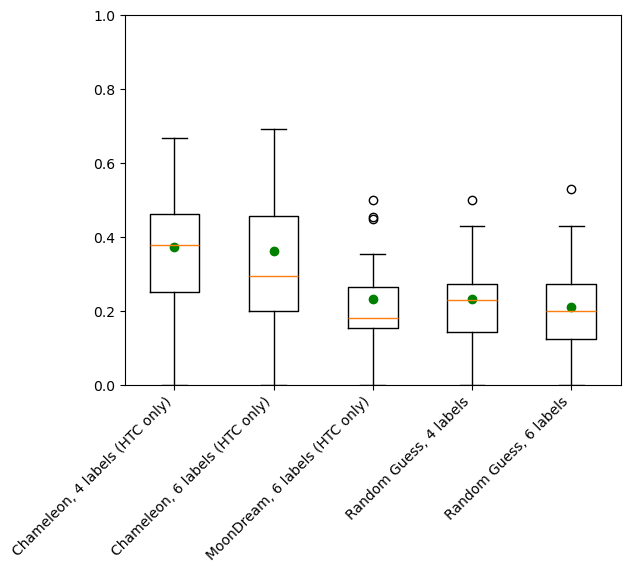

Median results: 0.3793103448275862 ##0.29411764705882354 ##0.18181818181818182 ##0.22807017543859648 ##0.2 ##
Mean results: 0.37293729372937295 ##0.36303630363036304 ##0.23102310231023102 ##0.23102310231023102 ##0.20957095709570958 ##[1 2 3 4 5 6]


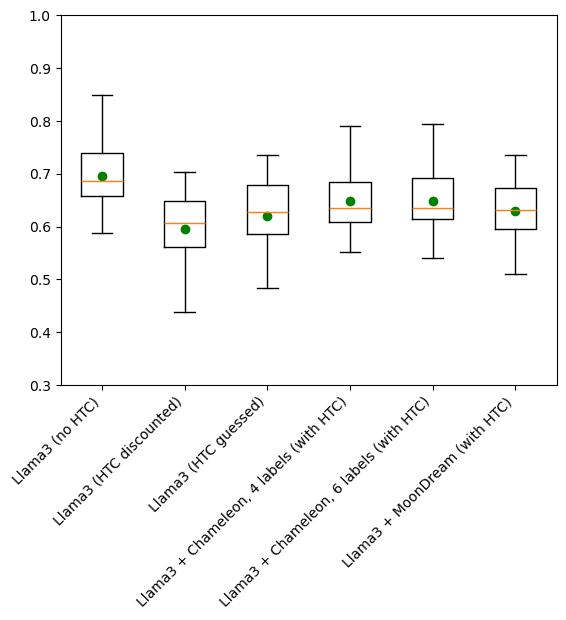

Median results: 0.6871794871794872 ##0.60625 ##0.6271186440677966 ##0.6349206349206349 ##0.6349206349206349 ##0.631578947368421 ##
Mean results: 0.6952459466886507 ##0.5959952885747939 ##0.620494699646643 ##0.6492343934040047 ##0.6478209658421673 ##0.6289752650176679 ##

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import mean, median

def plot_my_data(dataset_test_results, normal_mean_results, labels, y_lim_bottom = 0.0):
    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results_T = np.transpose(dataset_test_results)
    
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    x_positions = np.arange(1, len(labels) + 1)  # Numeric positions for box plots
    ax.boxplot(dataset_test_results_T, positions=x_positions, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(y_lim_bottom, 1.0)
    
    print(x_positions)
    # Line Plot (Secondary Axis)
    #ax1 = ax.twinx()  # Create secondary y-axis
    ax1 = ax
    ax1.scatter(x_positions, normal_mean_results, color='green', marker='o', label="Mean Value")  # Scatter instead of line
    
    plt.show()

    print("Median results: ", end='')
    for i in range(len(dataset_test_results)):
        print(median(dataset_test_results[i]), "##", end='')

    print("")
    
    print("Mean results: ", end='')
    for i in range(len(normal_mean_results)):
        print(normal_mean_results[i], "##", end='')

##
# This function will create a box plot for a hybridized data set (HYBRID_AT_12 or HYBRID_AT_18)
##
#def testAllRoomClassifiersAccuracy():
(llm_accuracies_fair, svc_accuracies, cvm_accuracies_cham, llm_mean_time, svc_mean_time, cvm_mean_time_cham, storages_and_offices_cham, normal_mean_scores_cham) = process_scene_files("CHAMELEON")
(_, _, cvm_accuracies_cham_fp, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp, normal_mean_scores_cham_fp) = process_scene_files("CHAMELEON_full_prompt")
(_, _, cvm_accuracies_cham_4l, llm_mean_time, svc_mean_time, cvm_mean_time_cham_4l, storages_and_offices_cham_4l, normal_mean_scores_cham_4l) = process_scene_files("CHAMELEON_4labels")
(_, _, cvm_accuracies_cham_fx, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fx, storages_and_offices_cham_fx, normal_mean_scores_cham_fx) = process_scene_files("CHAMELEON_fixed")
(_, _, cvm_accuracies_md_fp, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp, storages_and_offices_md_fp, normal_mean_scores_md_fp) = process_scene_files("MOONDREAM_full_prompt")
(_, _, cvm_accuracies_md_ow, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow, storages_and_offices_md_ow, normal_mean_scores_md_ow) = process_scene_files("MOONDREAM_one_word")

(_, _, cvm_accuracies_cham_fp_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp_llmtcvm, storages_and_offices_cham_fp_llmtcvm, normal_mean_scores_cham_fp_llmtcvm) = process_scene_files("CHAMELEON_full_prompt", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_cham_4l_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_4l_llmtcvm, storages_and_offices_cham_4l_llmtcvm, normal_mean_scores_cham_4l_llmtcvm) = process_scene_files("CHAMELEON_4labels", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_cham_fx_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fx_llmtcvm, storages_and_offices_cham_fx_llmtcvm, normal_mean_scores_cham_fx_llmtcvm) = process_scene_files("CHAMELEON_fixed", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_md_fp_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp_llmtcvm, storages_and_offices_md_fp_llmtcvm, normal_mean_scores_md_fp_llmtcvm) = process_scene_files("MOONDREAM_full_prompt", ClassifierFusionType.LLM_THEN_CVM)
(_, _, cvm_accuracies_md_ow_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow_llmtcvm, storages_and_offices_md_ow_llmtcvm, normal_mean_scores_md_ow_llmtcvm) = process_scene_files("MOONDREAM_one_word", ClassifierFusionType.LLM_THEN_CVM)

(_, _, cvm_accuracies_cham_fp_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp_cvmtllm, storages_and_offices_cham_fp_cvmtllm, normal_mean_scores_cham_fp_cvmtllm) = process_scene_files("CHAMELEON_full_prompt", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_cham_4l_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_4l_cvmtllm, storages_and_offices_cham_4l_cvmtllm, normal_mean_scores_cham_4l_cvmtllm) = process_scene_files("CHAMELEON_4labels", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_cham_fx_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fx_cvmtllm, storages_and_offices_cham_fx_cvmtllm, normal_mean_scores_cham_fx_cvmtllm) = process_scene_files("CHAMELEON_fixed", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_md_fp_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp_cvmtllm, storages_and_offices_md_fp_cvmtllm, normal_mean_scores_md_fp_cvmtllm) = process_scene_files("MOONDREAM_full_prompt", ClassifierFusionType.CVM_THEN_LLM)
(_, _, cvm_accuracies_md_ow_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow_cvmtllm, storages_and_offices_md_ow_cvmtllm, normal_mean_scores_md_ow_cvmtllm) = process_scene_files("MOONDREAM_one_word", ClassifierFusionType.CVM_THEN_LLM)
(llm_accuracies, _, _, llm_mean_time, svc_mean_time, _, _, normal_mean_scores_llama) = process_scene_files("LLAMA")

(_, _, cvm_accuracies_cham_fp_fair, _, _, _, _, normal_mean_scores_cham_fp_fair) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_cham_4l_fair, _, _, _, _, normal_mean_scores_cham_4l_fair) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_cham_fx_fair, _, _, _, _, normal_mean_scores_cham_fx_fair) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_md_fp_fair, _, _, _, _, normal_mean_scores_md_fp_fair) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
(_, _, cvm_accuracies_md_ow_fair, _, _, _, _, normal_mean_scores_md_ow_fair) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)

(_, _, cvm_accuracies_cham_fp_hard, _, _, _, _, normal_mean_scores_cham_fp_hard) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_4l_hard, _, _, _, _, normal_mean_scores_cham_4l_hard) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_fx_hard, _, _, _, _, normal_mean_scores_cham_fx_hard) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_fp_hard, _, _, _, _, normal_mean_scores_md_fp_hard) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_ow_hard, _, _, _, _, normal_mean_scores_md_ow_hard) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)

(_, _, cvm_accuracies_cham_fp_guess, _, _, _, _, normal_mean_scores_cham_fp_guess) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_4l_guess, _, _, _, _, normal_mean_scores_cham_4l_guess) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_cham_fx_guess, _, _, _, _, normal_mean_scores_cham_fx_guess) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_fp_guess, _, _, _, _, normal_mean_scores_md_fp_guess) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
(_, _, cvm_accuracies_md_ow_guess, _, _, _, _, normal_mean_scores_md_ow_guess) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)

(_, _, cvm_accuracies_cham_fp_llm_fail, _, _, _, _, normal_mean_scores_cham_fp_llm_fail) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_cham_4l_llm_fail, _, _, _, _, normal_mean_scores_cham_4l_llm_fail) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_cham_fx_llm_fail, _, _, _, _, normal_mean_scores_cham_fx_llm_fail) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_md_fp_llm_fail, _, _, _, _, normal_mean_scores_md_fp_llm_fail) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
(_, _, cvm_accuracies_md_ow_llm_fail, _, _, _, _, normal_mean_scores_md_ow_llm_fail) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)

(llm_accuracies_htc_guessed, _, _, _, _, _, _, normal_mean_scores_htc_guessed) = process_scene_files("CHAMELEON", what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM)

# should be two volumes -- one for LLM and one for SVC for accuracies compared to ground truth.
#number_of_dataset_volumes = 11

# How many rooms were classified
#number_of_tests_per_dataset_volume = len(svc_accuracies)
#print(str(len(svc_accuracies)) + " " + str(len(cvm_accuracies_cham)) + " " + str(len(cvm_accuracies_cham_fp)) + " " + str(len(cvm_accuracies_md_fp)) + " " + str(len(cvm_accuracies_md_ow)))
#print(str(storages_and_offices_cham) + " " + str(storages_and_offices_cham))

# We'll create an empty Numpy array and put the our SVC accuracies into there.
#dataset_test_results = np.zeros(shape=(number_of_dataset_volumes, number_of_tests_per_dataset_volume))
#print(dataset_test_results.shape)

#    dataset_test_results[0] = cvm_accuracies_cham
#    dataset_test_results[1] = cvm_accuracies_cham_fp
#    dataset_test_results[2] = cvm_accuracies_md_fp
#    dataset_test_results[3] = cvm_accuracies_md_ow
#    dataset_test_results[4] = svc_accuracies

#dataset_test_results = [cvm_accuracies_cham, cvm_accuracies_cham_fp, cvm_accuracies_md_fp, cvm_accuracies_md_ow, svc_accuracies]
dataset_test_results = [cvm_accuracies_cham_fp, cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp, cvm_accuracies_md_ow, 
                        svc_accuracies, 
                        cvm_accuracies_cham_fp_cvmtllm, cvm_accuracies_cham_4l_cvmtllm, cvm_accuracies_cham_fx_cvmtllm, cvm_accuracies_md_fp_cvmtllm, cvm_accuracies_md_ow_cvmtllm, 
                        cvm_accuracies_cham_fp_llmtcvm, cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm, cvm_accuracies_md_ow_llmtcvm, 
                        llm_accuracies, 
                        llm_accuracies_fair, 
                        llm_accuracies_htc_guessed,
                        cvm_accuracies_cham_fp_fair, cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, cvm_accuracies_md_ow_fair, 
                        cvm_accuracies_cham_fp_hard, cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, cvm_accuracies_md_ow_hard, 
                        cvm_accuracies_cham_fp_guess, cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess, cvm_accuracies_md_fp_guess, cvm_accuracies_md_ow_guess, 
                        cvm_accuracies_cham_fp_llm_fail, cvm_accuracies_cham_4l_llm_fail, cvm_accuracies_cham_fx_llm_fail, cvm_accuracies_md_fp_llm_fail, cvm_accuracies_md_ow_llm_fail]

normal_mean_results = [normal_mean_scores_cham_fp[2], normal_mean_scores_cham_4l[2], normal_mean_scores_cham_fx[2], normal_mean_scores_md_fp[2], normal_mean_scores_md_ow_cvmtllm[2],
                       normal_mean_scores_cham[1], 
                       normal_mean_scores_cham_fp_cvmtllm[2], normal_mean_scores_cham_4l_cvmtllm[2], normal_mean_scores_cham_fx_cvmtllm[2], normal_mean_scores_md_fp_cvmtllm[2], normal_mean_scores_md_ow_cvmtllm[2],
                       normal_mean_scores_cham_fp_llmtcvm[2], normal_mean_scores_cham_4l_llmtcvm[2], normal_mean_scores_cham_fx_llmtcvm[2], normal_mean_scores_md_fp_llmtcvm[2], normal_mean_scores_md_ow_llmtcvm[2],
                       normal_mean_scores_llama[0],
                       normal_mean_scores_cham[0],
                       normal_mean_scores_htc_guessed[0],
                       normal_mean_scores_cham_fp_fair[2], normal_mean_scores_cham_4l_fair[2], normal_mean_scores_cham_fx_fair[2], normal_mean_scores_md_fp_fair[2], normal_mean_scores_md_ow_fair[2],
                       normal_mean_scores_cham_fp_hard[2], normal_mean_scores_cham_4l_hard[2], normal_mean_scores_cham_fx_hard[2], normal_mean_scores_md_fp_hard[2], normal_mean_scores_md_ow_hard[2],
                       normal_mean_scores_cham_fp_guess[2], normal_mean_scores_cham_4l_guess[2], normal_mean_scores_cham_fx_guess[2], normal_mean_scores_md_fp_guess[2], normal_mean_scores_md_ow_guess[2],
                       normal_mean_scores_cham_fp_llm_fail[2], normal_mean_scores_cham_4l_llm_fail[2], normal_mean_scores_cham_fx_llm_fail[2], normal_mean_scores_md_fp_llm_fail[2], normal_mean_scores_md_ow_llm_fail[2]]

##print(dataset_test_results)
#fig, ax = plt.subplots()
#ax.axes.get_xaxis().set_visible(False)
##ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
##if (model_type == ModelType.HYBRID_AT_12):
##    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
##elif (model_type == ModelType.HYBRID_AT_18):
##    ax.set_title("Scannet - Hybridized with AI2-THOR data")
##ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
labels=['Chameleon', 'Chameleon-4l', 'Chameleon_fx', 'MoonDream fp', 'MoonDream ow', 
        'SVC', 
        'Chameleon_cl', 'Chameleon_cl-4l', 'Chameleon_cl_fx', 'MoonDream fp_cl', 'MoonDream ow_cl', 
        'Chameleon_lc', 'Chameleon_lc-4l', 'Chameleon_lc_fx', 'MoonDream fp_lc', 'MoonDream ow_lc', 
        'LLM', 
        'LLM-fair', 
        'LLM-HTC-guessed',
        'Chameleon_fair', 'Chameleon_fair-4l', 'Chameleon_fair_fx', 'MoonDream fp_fair', 'MoonDream ow_fair', 
        'Chameleon_hard', 'Chameleon_hard-4l', 'Chameleon_hard_fx', 'MoonDream fp_hard', 'MoonDream ow_hard', 
        'Chameleon_guess', 'Chameleon_guess-4l', 'Chameleon_guess_fx', 'MoonDream fp_guess', 'MoonDream ow_guess', 
        'Chameleon_llm_fail', 'Chameleon_llm_fail-4l', 'Chameleon_llm_fail_fx', 'MoonDream fp_llm_fail', 'MoonDream ow_llm_fail']

plot_my_data(dataset_test_results, normal_mean_results, labels)

print("cvm_mean_time_cham = " + str(cvm_mean_time_cham))
print("cvm_mean_time_cham_fp = " + str(cvm_mean_time_cham_fp))
print("cvm_mean_time_md_fp = " + str(cvm_mean_time_md_fp))
print("cvm_mean_time_md_ow = " + str(cvm_mean_time_md_ow))
print("svc_mean_time = " + str(svc_mean_time))


# Interim chart
dataset_test_results = [cvm_accuracies_cham, cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp, 
                        cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm, 
                        llm_accuracies, 
                        llm_accuracies_fair, 
                        llm_accuracies_htc_guessed,
                        cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, 
                        cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, 
                        cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess, cvm_accuracies_md_fp_guess]

normal_mean_results = [normal_mean_scores_cham[2], normal_mean_scores_cham_4l[2], normal_mean_scores_cham_fx[2], normal_mean_scores_md_fp[2],
                       normal_mean_scores_cham_4l_llmtcvm[2], normal_mean_scores_cham_fx_llmtcvm[2], normal_mean_scores_md_fp_llmtcvm[2],
                       normal_mean_scores_llama[0],
                       normal_mean_scores_cham[0],
                       normal_mean_scores_htc_guessed[0],
                       normal_mean_scores_cham_4l_fair[2], normal_mean_scores_cham_fx_fair[2], normal_mean_scores_md_fp_fair[2],
                       normal_mean_scores_cham_4l_hard[2], normal_mean_scores_cham_fx_hard[2], normal_mean_scores_md_fp_hard[2],
                       normal_mean_scores_cham_4l_guess[2], normal_mean_scores_cham_fx_guess[2], normal_mean_scores_md_fp_guess[2]]

labels=['Chameleon', 'Chameleon_4l', 'Chameleon_fx', 'MoonDream fp',
        'Chameleon_lc_4l', 'Chameleon_lc_fx', 'MoonDream fp_lc', 
        'LLM', 
        'LLM-fair', 
        'LLM-HTC-guessed',
        'Chameleon_fair_4l', 'Chameleon_fair_fx', 'MoonDream fp_fair', 
        'Chameleon_hard_4l', 'Chameleon_hard_fx', 'MoonDream fp_hard',  
        'Chameleon_guess_4l', 'Chameleon_guess_fx', 'MoonDream fp_guess']

plot_my_data(dataset_test_results, normal_mean_results, labels)
print("Median vals: " + str(median(llm_accuracies)) 
      + " ## " + str(median(llm_accuracies_fair)) 
      + " ## " + str(median(llm_accuracies_htc_guessed)) 
      + " ## " + str(median(cvm_accuracies_cham_4l_llmtcvm)) 
      + " ## " + str(median(cvm_accuracies_cham_fx_llmtcvm)) 
      + " ## " + str(median(cvm_accuracies_md_fp_llmtcvm)))

# CVM and LLM comparison
dataset_test_results = [llm_accuracies, cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, 
                        cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp]

normal_mean_results = [normal_mean_scores_llama[0], normal_mean_scores_cham_4l_fair[2], normal_mean_scores_cham_fx_fair[2], normal_mean_scores_md_fp_fair[2],
                       normal_mean_scores_cham_4l[2], normal_mean_scores_cham_fx[2], normal_mean_scores_md_fp[2]]

#print(dataset_test_results)

labels=['Llama3 (no HTC)', 'Chameleon, 4 labels (no HTC)', 'Chameleon, 6 labels (no HTC)', 'MoonDream, 6 labels (no HTC)', 
        'Chameleon, 4 labels (with HTC)', 'Chameleon, 6 labels (with HTC)', 'MoonDream, 6 labels (with HTC)']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.2)

# Hard part analysis
dataset_test_results = [cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, 
                        cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess]

normal_mean_results = [normal_mean_scores_cham_4l_hard[2], normal_mean_scores_cham_fx_hard[2], normal_mean_scores_md_fp_hard[2],
                       normal_mean_scores_cham_4l_guess[2], normal_mean_scores_cham_fx_guess[2]]

#print(dataset_test_results)

labels=['Chameleon, 4 labels (HTC only)', 'Chameleon, 6 labels (HTC only)', 'MoonDream, 6 labels (HTC only)',  
        'Random Guess, 4 labels', 'Random Guess, 6 labels']

plot_my_data(dataset_test_results, normal_mean_results, labels)

# Fused results
dataset_test_results = [llm_accuracies, 
                        llm_accuracies_fair,
                        llm_accuracies_htc_guessed,
                        cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm]

normal_mean_results = [normal_mean_scores_llama[0],
                       normal_mean_scores_cham[0],
                       normal_mean_scores_htc_guessed[0],
                       normal_mean_scores_cham_4l_llmtcvm[2], normal_mean_scores_cham_fx_llmtcvm[2], normal_mean_scores_md_fp_llmtcvm[2]]

labels=['Llama3 (no HTC)', 
        'Llama3 (HTC discounted)', 
        'Llama3 (HTC guessed)', 
        'Llama3 + Chameleon, 4 labels (with HTC)', 'Llama3 + Chameleon, 6 labels (with HTC)', 'Llama3 + MoonDream (with HTC)']

plot_my_data(dataset_test_results, normal_mean_results, labels, 0.3)

#print("Median vals: " + str(median(llm_accuracies)) + " ## " + str(median(llm_accuracies_fair)) + " ## " + str(median(llm_accuracies_htc_guessed)) + " ## " + str(median(cvm_accuracies_cham_4l_llmtcvm)) + " ## " + str(median(cvm_accuracies_cham_fx_llmtcvm)) + " ## " + str(median(cvm_accuracies_md_fp_llmtcvm)))


#testAllRoomClassifiersAccuracy()

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


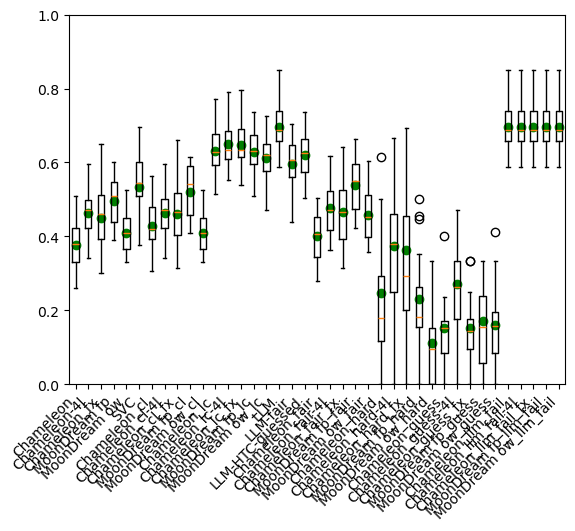

In [28]:
x_positions = np.arange(1, len(labels) + 1)  # Numeric positions for box plots
fig, ax = plt.subplots()
ax.axes.get_xaxis().set_visible(False)
ax.boxplot(dataset_test_results, positions=x_positions, labels=labels)
ax.axes.get_xaxis().set_visible(True)
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.ylim(0.0, 1.0)
#plt.xticks([1, 2, 3], ['mon', 'tue', 'wed'])

print(x_positions)
# Line Plot (Secondary Axis)
#ax1 = ax.twinx()  # Create secondary y-axis
ax1 = ax

ax1.scatter(x_positions, normal_mean_results, color='green', marker='o', label="Mean Value")  # Scatter instead of line

#ax1.plot(x_positions, normal_mean_results, color='red', linestyle='-', label="Mean Value")
#ax1.set_ylabel('Mean Value (Line Plot)')

# Title and Legend
#ax1.legend(loc="upper left")

plt.show()